# Higher Education Data Quality Audit
### IPEDS Dataset | DAMA DMBOK Framework
**Goal:** Identify and flag real data quality problems across key governance dimensions.

## Section 1: Setup
Importing libraries, configuring settings, and loading the IPEDS dataset.

In [ ]:
!pip install pandas numpy matplotlib seaborn missingno openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from IPython.display import display

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Load the data
# IPEDS files often use Latin-1 encoding
df1 = pd.read_csv('/content/drive/MyDrive/Datasets_for_IPEDS_Analysis/df1_enrollment_effy2024.csv', encoding='latin-1', low_memory=False)
df2 = pd.read_csv('/content/drive/MyDrive/Datasets_for_IPEDS_Analysis/df2_finances_f2324_f1a.csv', encoding='latin-1', low_memory=False)
df3 = pd.read_csv('/content/drive/MyDrive/Datasets_for_IPEDS_Analysis/df3_gradrate_gr2024.csv', encoding='latin-1', low_memory=False)
df4 = pd.read_csv('/content/drive/MyDrive/Datasets_for_IPEDS_Analysis/df4_directory_hd2024.csv', encoding='utf-8-sig', low_memory=False)
df5 = pd.read_csv('/content/drive/MyDrive/Datasets_for_IPEDS_Analysis/df5_characteristics_ic2024.csv', encoding='latin-1', low_memory=False)

In [ ]:
# Sanity check on each
for name, df in [('df1', df1), ('df2', df2), ('df3', df3), ('df4', df4), ('df5', df5)]:
    print(f"{name} — Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")

df1 — Rows: 115,026 | Columns: 72
df2 — Rows: 1,911 | Columns: 288
df3 — Rows: 51,011 | Columns: 66
df4 — Rows: 6,072 | Columns: 72
df5 — Rows: 5,963 | Columns: 111


In [ ]:
display(df1.head())

,UNITID,EFFYALEV,EFFYLEV,LSTUDY,XEYTOTLT,EFYTOTLT,XEYTOTLM,EFYTOTLM,XEYTOTLW,EFYTOTLW,XEFYAIAT,EFYAIANT,XEFYAIAM,EFYAIANM,XEFYAIAW,EFYAIANW,XEFYASIT,EFYASIAT,XEFYASIM,EFYASIAM,XEFYASIW,EFYASIAW,XEFYBKAT,EFYBKAAT,XEFYBKAM,...,EFY2MORT,XEFY2MOM,EFY2MORM,XEFY2MOW,EFY2MORW,XEYUNKNT,EFYUNKNT,XEYUNKNM,EFYUNKNM,XEYUNKNW,EFYUNKNW,XEYNRALT,EFYNRALT,XEYNRALM,EFYNRALM,XEYNRALW,EFYNRALW,XEFYGUUN,EFYGUUN,XEFYGUAN,EFYGUAN,XEFYGUTO,EFYGUTOT,XEFYGUKN,EFYGUKN
0,100654,1,1,999,R,7120,R,2919,R,4201,R,9,R,5,R,4,R,15,R,4,R,11,R,6038,R,...,115,R,44,R,71,R,480,R,166,R,314,R,197,R,120,R,77,R,51.00,A,NaN,R,51.00,R,7069.00
1,100654,2,2,1,R,6197,R,2602,R,3595,R,8,R,4,R,4,R,14,R,4,R,10,R,5473,R,...,115,R,44,R,71,R,238,R,89,R,149,R,119,R,75,R,44,R,39.00,A,NaN,R,39.00,R,6158.00
2,100654,3,-2,1,R,6043,R,2553,R,3490,R,7,R,3,R,4,R,12,R,3,R,9,R,5448,R,...,115,R,44,R,71,R,122,R,58,R,64,R,118,R,74,R,44,A,NaN,A,NaN,A,NaN,A,NaN
3,100654,4,-2,1,R,2103,R,881,R,1222,R,2,R,2,R,0,R,3,R,1,R,2,R,1915,R,...,63,R,24,R,39,R,1,R,1,R,0,R,59,R,36,R,23,A,NaN,A,NaN,A,NaN,A,NaN
4,100654,5,-2,1,R,3940,R,1672,R,2268,R,5,R,1,R,4,R,9,R,2,R,7,R,3533,R,...,52,R,20,R,32,R,121,R,57,R,64,R,59,R,38,R,21,A,NaN,A,NaN,A,NaN,A,NaN


In [ ]:
display(df2.head())
display(df3.head())

,UNITID,XF1A01,F1A01,XF1A31,F1A31,XF1A04,F1A04,XF1A05,F1A05,XF1A06,F1A06,XF1A19,F1A19,XF1A07,F1A07,XF1A08,F1A08,XF1A09,F1A09,XF1A10,F1A10,XF1A11,F1A11,XF1A12,F1A12,...,F1H02,XF1H03,F1H03,XF1H03A,F1H03A,XF1H03B,F1H03B,XF1H03C,F1H03C,XF1H03D,F1H03D,XF1N01,F1N01,XF1N02,F1N02,XF1N03,F1N03,XF1N04,F1N04,XF1N05,F1N05,XF1N06,F1N06,XF1N07,F1N07
0,100654,R,180654640.00,R,233194452.00,R,0.00,R,233194452.00,R,413849092.00,R,31296759.00,R,0.00,R,99445116.00,R,99445116.00,R,73285311.00,R,121457201.00,R,194742512.00,...,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,R,27984574.00,R,235478590.00,R,-26221592.00,R,115733869.00,R,-45362221.00,R,68084358.00,R,261700182.00
1,100663,R,2833081525.00,R,2285818610.00,R,2200177870.00,R,4485996480.00,R,7319078005.00,R,906267500.00,R,83576504.00,R,648366372.00,R,731942876.00,R,1214532763.00,R,1893226632.00,R,3107759395.00,...,858989211.00,R,119616297.00,R,34676076.00,R,84940221.00,R,-32303611.00,R,32303611.00,R,659497262.00,R,6574594533.00,R,763456300.00,R,5909441089.00,R,4390652464.00,R,13701248.00,R,5928840846.00
2,100706,R,256142215.00,R,293596035.00,R,194391213.00,R,487987248.00,R,744129463.00,R,106247331.00,R,7985213.00,R,85583922.00,R,93569135.00,R,130701913.00,R,252678469.00,R,383380382.00,...,113737648.00,R,14110629.00,R,2310128.00,R,11800501.00,R,-4328328.00,R,4328328.00,R,44410817.00,R,343548721.00,R,82454317.00,R,552663999.00,R,415154729.00,R,138687126.00,R,312285846.00
3,100724,R,152713630.00,R,236894734.00,R,774074.00,R,237668808.00,R,390382438.00,R,55801245.00,R,2851132.00,R,33479065.00,R,36330197.00,R,37455000.00,R,122746068.00,R,160201068.00,...,135198862.00,R,16582577.00,R,34443.00,R,12862982.00,R,-2671953.00,R,6357105.00,R,21345771.00,R,215713096.00,R,21345771.00,R,326873210.00,R,0.00,R,37455000.00,R,194367325.00
4,100733,R,9165526.00,R,16518993.00,R,15051737.00,R,31570730.00,R,40736256.00,R,12750377.00,Z,0.00,R,6086664.00,R,6086664.00,Z,0.00,R,29174695.00,R,29174695.00,...,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,R,1514354.00,R,162374208.00,R,1514354.00,R,9830457.00,R,5719837.00,R,0.00,R,160859854.00


,UNITID,GRTYPE,CHRTSTAT,SECTION,COHORT,LINE,XGRTOTLT,GRTOTLT,XGRTOTLM,GRTOTLM,XGRTOTLW,GRTOTLW,XGRAIANT,GRAIANT,XGRAIANM,GRAIANM,XGRAIANW,GRAIANW,XGRASIAT,GRASIAT,XGRASIAM,GRASIAM,XGRASIAW,GRASIAW,XGRBKAAT,...,GRNHPIW,XGRWHITT,GRWHITT,XGRWHITM,GRWHITM,XGRWHITW,GRWHITW,XGR2MORT,GR2MORT,XGR2MORM,GR2MORM,XGR2MORW,GR2MORW,XGRUNKNT,GRUNKNT,XGRUNKNM,GRUNKNM,XGRUNKNW,GRUNKNW,XGRNRALT,GRNRALT,XGRNRALM,GRNRALM,XGRNRALW,GRNRALW
0,100654,1,10,1,1,999,R,1402,R,571.00,R,831.00,R,3.00,R,2.00,R,1.00,R,2.00,R,1.00,R,1.00,R,...,1.00,R,17.00,R,12.00,R,5.00,R,18.00,R,2.00,R,16.00,R,50.00,R,25.00,R,25.00,R,3.00,R,1.00,R,2.00
1,100654,2,12,1,1,999,R,1398,R,571.00,R,827.00,R,3.00,R,2.00,R,1.00,R,2.00,R,1.00,R,1.00,R,...,1.00,R,17.00,R,12.00,R,5.00,R,17.00,R,2.00,R,15.00,R,50.00,R,25.00,R,25.00,R,3.00,R,1.00,R,2.00
2,100654,3,13,1,1,999,R,336,R,112.00,R,224.00,R,1.00,R,1.00,R,0.00,R,1.00,R,1.00,R,0.00,R,...,0.00,R,5.00,R,4.00,R,1.00,R,5.00,R,2.00,R,3.00,R,13.00,R,3.00,R,10.00,R,1.00,R,1.00,R,0.00
3,100654,4,20,1,1,999,R,457,R,175.00,R,282.00,R,0.00,R,0.00,R,0.00,R,0.00,R,0.00,R,0.00,R,...,0.00,R,5.00,R,3.00,R,2.00,R,7.00,R,0.00,R,7.00,R,10.00,R,5.00,R,5.00,R,0.00,R,0.00,R,0.00
4,100654,6,10,2,2,10,R,1402,R,571.00,R,831.00,R,3.00,R,2.00,R,1.00,R,2.00,R,1.00,R,1.00,R,...,1.00,R,17.00,R,12.00,R,5.00,R,18.00,R,2.00,R,16.00,R,50.00,R,25.00,R,25.00,R,3.00,R,1.00,R,2.00


In [ ]:
display(df4.head())
display(df5.head())

,UNITID,INSTNM,IALIAS,ADDR,CITY,STABBR,ZIP,FIPS,OBEREG,CHFNM,CHFTITLE,GENTELE,EIN,UEIS,OPEID,OPEFLAG,WEBADDR,ADMINURL,FAIDURL,APPLURL,NPRICURL,VETURL,ATHURL,DISAURL,SECTOR,...,INSTCAT,C00CARNEGIE,C21BASIC,CARNEGIEIC,CARNEGIESAEC,CARNEGIERSCH,CARNEGIESIZE,CARNEGIEALF,CARNEGIEAPM,CARNEGIEGPM,LANDGRNT,INSTSIZE,F1SYSTYP,F1SYSNAM,F1SYSCOD,CBSA,CBSATYPE,CSA,COUNTYCD,COUNTYNM,CNGDSTCD,LONGITUD,LATITUDE,DFRCGID,DFRCUSCG
0,100654,Alabama A & M University,AAMU,4900 Meridian Street,Normal,AL,35762,1,5,Dr. Daniel K. Wims,President,2563725000.00,636001097,JDVGS67MSLH7,100200.00,1,www.aamu.edu/,https://www.aamu.edu/admissions-aid/index.html,https://www.aamu.edu/admissions-aid/financial-...,https://www.aamu.edu/admissions-aid/undergradu...,www.aamu.edu/admissions-aid/tuition-fees/net-p...,NaN,NaN,https://www.aamu.edu/administrativeoffices/VAD...,1,...,2,16,18,9,4,3,3,4,1,2,1,3,2,-2,-2,26620,1,290,1089,Madison County,105,-86.57,34.78,106,1
1,100663,University of Alabama at Birmingham,UAB,Administration Bldg Suite 1070,Birmingham,AL,35294-0110,1,5,Ray L. Watts,President,2059344011.00,636005396,YND4PLMC9AN7,105200.00,1,https://www.uab.edu/,https://www.uab.edu/admissions/,https://www.uab.edu/cost-aid/,https://www.uab.edu/admissions/apply,https://tcc.ruffalonl.com/University of Alabam...,https://www.uab.edu/students/veterans,https://www.uab.edu/registrar/students,https://www.uab.edu/students/disability/,1,...,2,15,15,16,4,1,4,5,2,8,2,5,1,The University of Alabama System,101050,13820,1,142,1073,Jefferson County,107,-86.80,33.51,91,1
2,100690,Amridge University,Southern Christian University Regions University,1200 Taylor Rd,Montgomery,AL,36117-3553,1,5,Michael C.Turner,President,33438700000000.00,237034324,RB27R4GLDKE7,2503400.00,1,https://www.amridgeuniversity.edu/,https://www.amridgeuniversity.edu/admissions/,https://www.amridgeuniversity.edu/financialaid/,https://www.amridgeuniversity.edu/myamridge/,https://www2.amridgeuniversity.edu:9091/,https://www.amridgeuniversity.edu/admissions/m...,NaN,https://www.amridgeuniversity.edu/studentservi...,2,...,2,51,20,25,-2,-2,2,6,1,2,2,1,2,-2,-2,33860,1,388,1101,Montgomery County,102,-86.17,32.36,125,2
3,100706,University of Alabama in Huntsville,UAH University of Alabama Huntsville,301 Sparkman Dr,Huntsville,AL,35899,1,5,Chuck Karr,President,2568246120.00,630520830,HB6KNGVNJRU1,105500.00,1,www.uah.edu/,https://www.uah.edu/admissions,finaid.uah.edu/,www.uah.edu/admissions/undergraduate/apply-for...,uah.clearcostcalculator.com/student/default/ne...,www.uah.edu/admissions/graduate/financial-aid/...,www.uah.edu/heoa,www.uah.edu/health-and-wellness/disability-sup...,1,...,2,16,15,7,5,2,3,5,1,2,2,3,1,The University of Alabama System,101050,26620,1,290,1089,Madison County,105,-86.64,34.72,91,2
4,100724,Alabama State University,NaN,915 S Jackson Street,Montgomery,AL,36104-0271,1,5,Quinton T. Ross,President,3342294100.00,636001101,DLJWLMSNK627,100500.00,1,www.alasu.edu/,www.alasu.edu/admissions/index.aspx,www.alasu.edu/_qa/financial-aid.php,www.alasu.edu/admissions/undergrad-admissions/...,tcc.ruffalonl.com/Alabama State University/Fre...,NaN,https://www.alasu.edu/_qa/institutional-data.php,www.alasu.edu/_qa/office-disability-services.php,1,...,2,21,17,22,4,3,3,3,4,2,2,2,2,-2,-2,33860,1,388,1101,Montgomery County,102,-86.30,32.36,97,1


,UNITID,PEO1ISTR,PEO2ISTR,PEO3ISTR,PEO4ISTR,PEO5ISTR,PEO6ISTR,PEO7ISTR,CNTLAFFI,PUBPRIME,PUBSECON,RELAFFIL,LEVEL1,LEVEL1A,LEVEL1B,LEVEL2,LEVEL3,LEVEL4,LEVEL5,LEVEL6,LEVEL7,LEVEL8,LEVEL12,LEVEL17,LEVEL18,...,DSTNGN,DISTCRS,DISTPGS,DSTNCED1,DSTNCED2,DSTNCED3,DISTNCED,DISAB,XDISABPC,DISABPCT,ATHASSOC,ASSOC1,ASSOC2,ASSOC3,ASSOC4,ASSOC5,ASSOC6,SPORT1,CONFNO1,SPORT2,CONFNO2,SPORT3,CONFNO3,SPORT4,CONFNO4
0,100654,0,1,0,0,0,0,0,1,2,0,-2,0,0,0,0,0,0,1,0,1,1,0,1,0,...,0,1,1,1,1,0,2,2,R,3.42,1,1,0,0,0,0,0,1,133,1,133,1,133,1,133
1,100663,0,1,1,0,0,0,0,1,2,0,-2,1,0,1,1,0,0,1,1,1,1,0,1,1,...,0,1,1,1,1,0,2,2,R,6.66,1,1,0,0,0,0,0,1,372,1,372,1,372,1,372
2,100690,0,1,0,0,0,0,0,4,-2,-2,74,0,0,0,0,1,0,1,0,1,0,0,1,0,...,0,1,1,1,1,0,1,1,A,NaN,2,0,0,0,0,0,0,2,-2,2,-2,2,-2,2,-2
3,100706,0,1,1,1,0,0,0,1,2,0,-2,1,0,1,0,0,0,1,1,1,1,0,1,1,...,0,1,1,1,1,0,2,2,R,5.43,1,1,0,0,0,0,0,2,-2,1,146,1,146,1,146
4,100724,1,1,0,0,0,0,1,1,2,0,-2,0,0,0,0,0,0,1,1,1,1,0,1,1,...,0,1,1,1,1,0,2,1,A,NaN,1,1,0,0,0,0,0,1,133,1,133,1,133,1,133


## Section 2: Data Profiling
Getting a high-level view of each dataset before diving into quality dimensions.

In [ ]:
# Column names and Data types

for name, df in [('df1', df1), ('df2', df2), ('df3', df3), ('df4', df4), ('df5', df5)]:
  print(f"\n{'='*50}")
  print(f"  {name} Profile")
  print(f"{'='*50}")
  print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
  print(f"\nColumn Names & Data Types:")
  print(df.dtypes)
  print(f"\nFirst 3 Rows:")
  display(df.head(3))


  df1 Profile
Rows: 115,026 | Columns: 72

Column Names & Data Types:
UNITID        int64
EFFYALEV      int64
EFFYLEV       int64
LSTUDY        int64
XEYTOTLT     object
             ...   
EFYGUAN     float64
XEFYGUTO     object
EFYGUTOT    float64
XEFYGUKN     object
EFYGUKN     float64
Length: 72, dtype: object

First 3 Rows:


,UNITID,EFFYALEV,EFFYLEV,LSTUDY,XEYTOTLT,EFYTOTLT,XEYTOTLM,EFYTOTLM,XEYTOTLW,EFYTOTLW,XEFYAIAT,EFYAIANT,XEFYAIAM,EFYAIANM,XEFYAIAW,EFYAIANW,XEFYASIT,EFYASIAT,XEFYASIM,EFYASIAM,XEFYASIW,EFYASIAW,XEFYBKAT,EFYBKAAT,XEFYBKAM,...,EFY2MORT,XEFY2MOM,EFY2MORM,XEFY2MOW,EFY2MORW,XEYUNKNT,EFYUNKNT,XEYUNKNM,EFYUNKNM,XEYUNKNW,EFYUNKNW,XEYNRALT,EFYNRALT,XEYNRALM,EFYNRALM,XEYNRALW,EFYNRALW,XEFYGUUN,EFYGUUN,XEFYGUAN,EFYGUAN,XEFYGUTO,EFYGUTOT,XEFYGUKN,EFYGUKN
0,100654,1,1,999,R,7120,R,2919,R,4201,R,9,R,5,R,4,R,15,R,4,R,11,R,6038,R,...,115,R,44,R,71,R,480,R,166,R,314,R,197,R,120,R,77,R,51.00,A,NaN,R,51.00,R,7069.00
1,100654,2,2,1,R,6197,R,2602,R,3595,R,8,R,4,R,4,R,14,R,4,R,10,R,5473,R,...,115,R,44,R,71,R,238,R,89,R,149,R,119,R,75,R,44,R,39.00,A,NaN,R,39.00,R,6158.00
2,100654,3,-2,1,R,6043,R,2553,R,3490,R,7,R,3,R,4,R,12,R,3,R,9,R,5448,R,...,115,R,44,R,71,R,122,R,58,R,64,R,118,R,74,R,44,A,NaN,A,NaN,A,NaN,A,NaN



  df2 Profile
Rows: 1,911 | Columns: 288

Column Names & Data Types:
UNITID      int64
XF1A01     object
F1A01     float64
XF1A31     object
F1A31     float64
           ...   
F1N05     float64
XF1N06     object
F1N06     float64
XF1N07     object
F1N07     float64
Length: 288, dtype: object

First 3 Rows:


,UNITID,XF1A01,F1A01,XF1A31,F1A31,XF1A04,F1A04,XF1A05,F1A05,XF1A06,F1A06,XF1A19,F1A19,XF1A07,F1A07,XF1A08,F1A08,XF1A09,F1A09,XF1A10,F1A10,XF1A11,F1A11,XF1A12,F1A12,...,F1H02,XF1H03,F1H03,XF1H03A,F1H03A,XF1H03B,F1H03B,XF1H03C,F1H03C,XF1H03D,F1H03D,XF1N01,F1N01,XF1N02,F1N02,XF1N03,F1N03,XF1N04,F1N04,XF1N05,F1N05,XF1N06,F1N06,XF1N07,F1N07
0,100654,R,180654640.00,R,233194452.00,R,0.00,R,233194452.00,R,413849092.00,R,31296759.00,R,0.00,R,99445116.00,R,99445116.00,R,73285311.00,R,121457201.00,R,194742512.00,...,NaN,A,NaN,A,NaN,A,NaN,A,NaN,A,NaN,R,27984574.00,R,235478590.00,R,-26221592.00,R,115733869.00,R,-45362221.00,R,68084358.00,R,261700182.00
1,100663,R,2833081525.00,R,2285818610.00,R,2200177870.00,R,4485996480.00,R,7319078005.00,R,906267500.00,R,83576504.00,R,648366372.00,R,731942876.00,R,1214532763.00,R,1893226632.00,R,3107759395.00,...,858989211.00,R,119616297.00,R,34676076.00,R,84940221.00,R,-32303611.00,R,32303611.00,R,659497262.00,R,6574594533.00,R,763456300.00,R,5909441089.00,R,4390652464.00,R,13701248.00,R,5928840846.00
2,100706,R,256142215.00,R,293596035.00,R,194391213.00,R,487987248.00,R,744129463.00,R,106247331.00,R,7985213.00,R,85583922.00,R,93569135.00,R,130701913.00,R,252678469.00,R,383380382.00,...,113737648.00,R,14110629.00,R,2310128.00,R,11800501.00,R,-4328328.00,R,4328328.00,R,44410817.00,R,343548721.00,R,82454317.00,R,552663999.00,R,415154729.00,R,138687126.00,R,312285846.00



  df3 Profile
Rows: 51,011 | Columns: 66

Column Names & Data Types:
UNITID        int64
GRTYPE        int64
CHRTSTAT      int64
SECTION       int64
COHORT        int64
             ...   
GRNRALT     float64
XGRNRALM     object
GRNRALM     float64
XGRNRALW     object
GRNRALW     float64
Length: 66, dtype: object

First 3 Rows:


,UNITID,GRTYPE,CHRTSTAT,SECTION,COHORT,LINE,XGRTOTLT,GRTOTLT,XGRTOTLM,GRTOTLM,XGRTOTLW,GRTOTLW,XGRAIANT,GRAIANT,XGRAIANM,GRAIANM,XGRAIANW,GRAIANW,XGRASIAT,GRASIAT,XGRASIAM,GRASIAM,XGRASIAW,GRASIAW,XGRBKAAT,...,GRNHPIW,XGRWHITT,GRWHITT,XGRWHITM,GRWHITM,XGRWHITW,GRWHITW,XGR2MORT,GR2MORT,XGR2MORM,GR2MORM,XGR2MORW,GR2MORW,XGRUNKNT,GRUNKNT,XGRUNKNM,GRUNKNM,XGRUNKNW,GRUNKNW,XGRNRALT,GRNRALT,XGRNRALM,GRNRALM,XGRNRALW,GRNRALW
0,100654,1,10,1,1,999,R,1402,R,571.00,R,831.00,R,3.00,R,2.00,R,1.00,R,2.00,R,1.00,R,1.00,R,...,1.00,R,17.00,R,12.00,R,5.00,R,18.00,R,2.00,R,16.00,R,50.00,R,25.00,R,25.00,R,3.00,R,1.00,R,2.00
1,100654,2,12,1,1,999,R,1398,R,571.00,R,827.00,R,3.00,R,2.00,R,1.00,R,2.00,R,1.00,R,1.00,R,...,1.00,R,17.00,R,12.00,R,5.00,R,17.00,R,2.00,R,15.00,R,50.00,R,25.00,R,25.00,R,3.00,R,1.00,R,2.00
2,100654,3,13,1,1,999,R,336,R,112.00,R,224.00,R,1.00,R,1.00,R,0.00,R,1.00,R,1.00,R,0.00,R,...,0.00,R,5.00,R,4.00,R,1.00,R,5.00,R,2.00,R,3.00,R,13.00,R,3.00,R,10.00,R,1.00,R,1.00,R,0.00



  df4 Profile
Rows: 6,072 | Columns: 72

Column Names & Data Types:
UNITID        int64
INSTNM       object
IALIAS       object
ADDR         object
CITY         object
             ...   
CNGDSTCD      int64
LONGITUD    float64
LATITUDE    float64
DFRCGID       int64
DFRCUSCG      int64
Length: 72, dtype: object

First 3 Rows:


,UNITID,INSTNM,IALIAS,ADDR,CITY,STABBR,ZIP,FIPS,OBEREG,CHFNM,CHFTITLE,GENTELE,EIN,UEIS,OPEID,OPEFLAG,WEBADDR,ADMINURL,FAIDURL,APPLURL,NPRICURL,VETURL,ATHURL,DISAURL,SECTOR,...,INSTCAT,C00CARNEGIE,C21BASIC,CARNEGIEIC,CARNEGIESAEC,CARNEGIERSCH,CARNEGIESIZE,CARNEGIEALF,CARNEGIEAPM,CARNEGIEGPM,LANDGRNT,INSTSIZE,F1SYSTYP,F1SYSNAM,F1SYSCOD,CBSA,CBSATYPE,CSA,COUNTYCD,COUNTYNM,CNGDSTCD,LONGITUD,LATITUDE,DFRCGID,DFRCUSCG
0,100654,Alabama A & M University,AAMU,4900 Meridian Street,Normal,AL,35762,1,5,Dr. Daniel K. Wims,President,2563725000.00,636001097,JDVGS67MSLH7,100200.00,1,www.aamu.edu/,https://www.aamu.edu/admissions-aid/index.html,https://www.aamu.edu/admissions-aid/financial-...,https://www.aamu.edu/admissions-aid/undergradu...,www.aamu.edu/admissions-aid/tuition-fees/net-p...,NaN,NaN,https://www.aamu.edu/administrativeoffices/VAD...,1,...,2,16,18,9,4,3,3,4,1,2,1,3,2,-2,-2,26620,1,290,1089,Madison County,105,-86.57,34.78,106,1
1,100663,University of Alabama at Birmingham,UAB,Administration Bldg Suite 1070,Birmingham,AL,35294-0110,1,5,Ray L. Watts,President,2059344011.00,636005396,YND4PLMC9AN7,105200.00,1,https://www.uab.edu/,https://www.uab.edu/admissions/,https://www.uab.edu/cost-aid/,https://www.uab.edu/admissions/apply,https://tcc.ruffalonl.com/University of Alabam...,https://www.uab.edu/students/veterans,https://www.uab.edu/registrar/students,https://www.uab.edu/students/disability/,1,...,2,15,15,16,4,1,4,5,2,8,2,5,1,The University of Alabama System,101050,13820,1,142,1073,Jefferson County,107,-86.80,33.51,91,1
2,100690,Amridge University,Southern Christian University Regions University,1200 Taylor Rd,Montgomery,AL,36117-3553,1,5,Michael C.Turner,President,33438700000000.00,237034324,RB27R4GLDKE7,2503400.00,1,https://www.amridgeuniversity.edu/,https://www.amridgeuniversity.edu/admissions/,https://www.amridgeuniversity.edu/financialaid/,https://www.amridgeuniversity.edu/myamridge/,https://www2.amridgeuniversity.edu:9091/,https://www.amridgeuniversity.edu/admissions/m...,NaN,https://www.amridgeuniversity.edu/studentservi...,2,...,2,51,20,25,-2,-2,2,6,1,2,2,1,2,-2,-2,33860,1,388,1101,Montgomery County,102,-86.17,32.36,125,2



  df5 Profile
Rows: 5,963 | Columns: 111

Column Names & Data Types:
UNITID      int64
PEO1ISTR    int64
PEO2ISTR    int64
PEO3ISTR    int64
PEO4ISTR    int64
            ...  
CONFNO2     int64
SPORT3      int64
CONFNO3     int64
SPORT4      int64
CONFNO4     int64
Length: 111, dtype: object

First 3 Rows:


,UNITID,PEO1ISTR,PEO2ISTR,PEO3ISTR,PEO4ISTR,PEO5ISTR,PEO6ISTR,PEO7ISTR,CNTLAFFI,PUBPRIME,PUBSECON,RELAFFIL,LEVEL1,LEVEL1A,LEVEL1B,LEVEL2,LEVEL3,LEVEL4,LEVEL5,LEVEL6,LEVEL7,LEVEL8,LEVEL12,LEVEL17,LEVEL18,...,DSTNGN,DISTCRS,DISTPGS,DSTNCED1,DSTNCED2,DSTNCED3,DISTNCED,DISAB,XDISABPC,DISABPCT,ATHASSOC,ASSOC1,ASSOC2,ASSOC3,ASSOC4,ASSOC5,ASSOC6,SPORT1,CONFNO1,SPORT2,CONFNO2,SPORT3,CONFNO3,SPORT4,CONFNO4
0,100654,0,1,0,0,0,0,0,1,2,0,-2,0,0,0,0,0,0,1,0,1,1,0,1,0,...,0,1,1,1,1,0,2,2,R,3.42,1,1,0,0,0,0,0,1,133,1,133,1,133,1,133
1,100663,0,1,1,0,0,0,0,1,2,0,-2,1,0,1,1,0,0,1,1,1,1,0,1,1,...,0,1,1,1,1,0,2,2,R,6.66,1,1,0,0,0,0,0,1,372,1,372,1,372,1,372
2,100690,0,1,0,0,0,0,0,4,-2,-2,74,0,0,0,0,1,0,1,0,1,0,0,1,0,...,0,1,1,1,1,0,1,1,A,NaN,2,0,0,0,0,0,0,2,-2,2,-2,2,-2,2,-2


In [ ]:
# Missing values count

for name, df in [('df1', df1), ('df2', df2), ('df3', df3), ('df4', df4), ('df5', df5)]:
  missing = df.isnull().sum()
  missing_pct = (missing / len(df) * 100).round(2)
  missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
  missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

  print(f"\n{'='*50}")
  print(f"  {name} - Missing Values")
  print(f"{'='*50}")
  if missing_df.empty:
    print("No missing values found")
  else:
      display(missing_df)



  df1 - Missing Values


,Missing Count,Missing %
EFYGUAN,112340,97.66
EFYGUTOT,103167,89.69
EFYGUKN,103099,89.63
EFYGUUN,101533,88.27



  df2 - Missing Values


,Missing Count,Missing %
F1B07,1111,58.14
F1C121,1111,58.14
F1C122,1111,58.14
F1C131,1111,58.14
F1C132,1111,58.14
...,...,...
F1E131,62,3.24
F1E13,62,3.24
F1E122,62,3.24
F1E172,62,3.24



  df3 - Missing Values


,Missing Count,Missing %
GRTOTLM,3623,7.10
GRTOTLW,3623,7.10
GRAIANT,3623,7.10
GRAIANM,3623,7.10
GRAIANW,3623,7.10
GRASIAT,3623,7.10
GRASIAM,3623,7.10
GRASIAW,3623,7.10
GRBKAAT,3623,7.10
GRBKAAM,3623,7.10



  df4 - Missing Values


,Missing Count,Missing %
ATHURL,4359,71.79
IALIAS,3879,63.88
VETURL,2289,37.70
APPLURL,1278,21.05
FAIDURL,832,13.70
ADMINURL,831,13.69
UEIS,535,8.81
NPRICURL,200,3.29
DISAURL,113,1.86
CHFTITLE,71,1.17



  df5 - Missing Values


,Missing Count,Missing %
DISABPCT,4243,71.16


In [ ]:
#Descriptive statistics

for name, df in [('df1', df1), ('df2', df2), ('df3', df3), ('df4', df4), ('df5', df5)]:
  print(f"\n{'='*50}")
  print(f"  {name} - Descriptive Statistics")
  print(f"{'='*50}")
  display(df.describe(include='all'))


  df1 - Descriptive Statistics


,UNITID,EFFYALEV,EFFYLEV,LSTUDY,XEYTOTLT,EFYTOTLT,XEYTOTLM,EFYTOTLM,XEYTOTLW,EFYTOTLW,XEFYAIAT,EFYAIANT,XEFYAIAM,EFYAIANM,XEFYAIAW,EFYAIANW,XEFYASIT,EFYASIAT,XEFYASIM,EFYASIAM,XEFYASIW,EFYASIAW,XEFYBKAT,EFYBKAAT,XEFYBKAM,...,EFY2MORT,XEFY2MOM,EFY2MORM,XEFY2MOW,EFY2MORW,XEYUNKNT,EFYUNKNT,XEYUNKNM,EFYUNKNM,XEYUNKNW,EFYUNKNW,XEYNRALT,EFYNRALT,XEYNRALM,EFYNRALM,XEYNRALW,EFYNRALW,XEFYGUUN,EFYGUUN,XEFYGUAN,EFYGUAN,XEFYGUTO,EFYGUTOT,XEFYGUKN,EFYGUKN
count,115026.00,115026.00,115026.00,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,...,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,115026.00,115026,13493.00,115026,2686.00,115026,11859.00,115026,11927.00
unique,NaN,NaN,NaN,NaN,2,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,...,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,4,NaN,4,NaN,4,NaN
top,NaN,NaN,NaN,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,...,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,A,NaN,A,NaN,A,NaN,A,NaN
freq,NaN,NaN,NaN,NaN,114958,NaN,113113,NaN,113250,NaN,91975,NaN,83404,NaN,88087,NaN,100238,NaN,92588,NaN,96917,NaN,107355,NaN,101581,...,NaN,93044,NaN,98584,NaN,98772,NaN,92339,NaN,95709,NaN,88621,NaN,84752,NaN,84452,NaN,101465,NaN,110638,NaN,101465,NaN,101465,NaN
mean,264946.08,25.81,-1.55,140.27,NaN,1839.35,NaN,775.89,NaN,1063.47,NaN,12.84,NaN,4.81,NaN,8.03,NaN,125.20,NaN,57.81,NaN,67.40,NaN,243.40,NaN,...,75.73,NaN,31.39,NaN,44.34,NaN,90.90,NaN,41.91,NaN,48.98,NaN,67.90,NaN,36.28,NaN,31.62,NaN,55.18,NaN,39.67,NaN,66.22,NaN,3861.68
std,133396.04,17.46,1.29,345.68,NaN,5681.70,NaN,2475.51,NaN,3299.76,NaN,65.54,NaN,23.80,NaN,43.23,NaN,582.44,NaN,285.34,NaN,301.75,NaN,950.00,NaN,...,250.08,NaN,107.76,NaN,145.80,NaN,627.79,NaN,298.31,NaN,348.13,NaN,393.45,NaN,222.57,NaN,177.51,NaN,495.57,NaN,127.36,NaN,500.67,NaN,9645.28
min,100654.00,1.00,-2.00,1.00,NaN,1.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,...,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00
25%,163426.00,11.00,-2.00,1.00,NaN,76.00,NaN,14.00,NaN,44.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,1.00,NaN,0.00,NaN,0.00,NaN,5.00,NaN,...,1.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,173.00
50%,210492.00,23.00,-2.00,1.00,NaN,310.00,NaN,101.00,NaN,192.00,NaN,1.00,NaN,0.00,NaN,1.00,NaN,6.00,NaN,2.00,NaN,3.00,NaN,34.00,NaN,...,8.00,NaN,2.00,NaN,5.00,NaN,6.00,NaN,2.00,NaN,3.00,NaN,1.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,735.00
75%,428125.00,41.00,-2.00,1.00,NaN,1355.00,NaN,558.00,NaN,796.00,NaN,6.00,NaN,2.00,NaN,4.00,NaN,37.00,NaN,15.00,NaN,22.00,NaN,149.00,NaN,...,47.00,NaN,19.00,NaN,28.00,NaN,42.00,NaN,17.00,NaN,23.00,NaN,18.00,NaN,9.00,NaN,8.00,NaN,2.00,NaN,22.00,NaN,3.00,NaN,3262.50



  df2 - Descriptive Statistics


,UNITID,XF1A01,F1A01,XF1A31,F1A31,XF1A04,F1A04,XF1A05,F1A05,XF1A06,F1A06,XF1A19,F1A19,XF1A07,F1A07,XF1A08,F1A08,XF1A09,F1A09,XF1A10,F1A10,XF1A11,F1A11,XF1A12,F1A12,...,F1H02,XF1H03,F1H03,XF1H03A,F1H03A,XF1H03B,F1H03B,XF1H03C,F1H03C,XF1H03D,F1H03D,XF1N01,F1N01,XF1N02,F1N02,XF1N03,F1N03,XF1N04,F1N04,XF1N05,F1N05,XF1N06,F1N06,XF1N07,F1N07
count,1911.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00,...,1331.00,1911,1331.00,1911,1331.00,1911,1331.00,1911,1331.00,1911,1331.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00,1911,1486.00
unique,NaN,2,NaN,3,NaN,3,NaN,3,NaN,2,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,...,NaN,3,NaN,3,NaN,3,NaN,3,NaN,3,NaN,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN,2,NaN
top,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,...,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN
freq,NaN,1486,NaN,1483,NaN,1485,NaN,1483,NaN,1486,NaN,1474,NaN,1463,NaN,1485,NaN,1485,NaN,1439,NaN,1485,NaN,1484,NaN,...,NaN,1330,NaN,1330,NaN,1330,NaN,1330,NaN,1330,NaN,1486,NaN,1486,NaN,1486,NaN,1486,NaN,1486,NaN,1486,NaN,1486,NaN
mean,215461.24,NaN,163592055.03,NaN,323581270.48,NaN,261867409.26,NaN,585448679.74,NaN,749040726.03,NaN,42891043.74,NaN,12437464.16,NaN,74755109.89,NaN,87192574.05,NaN,161107988.02,NaN,166792269.98,NaN,327900258.00,...,243139490.68,NaN,19570046.87,NaN,6727774.80,NaN,20776635.62,NaN,-8651807.43,NaN,717443.88,NaN,22602782.70,NaN,354566386.59,NaN,44172166.06,NaN,485272406.94,NaN,219834217.90,NaN,155103834.76,NaN,335076494.39
std,98989.19,NaN,606028810.52,NaN,1434675092.18,NaN,2331034419.36,NaN,3476262864.50,NaN,4004170671.74,NaN,255392467.57,NaN,92024028.94,NaN,531705761.49,NaN,614116162.55,NaN,969148545.93,NaN,1254095528.76,NaN,2179819688.64,...,1682982416.29,NaN,113254790.83,NaN,37054130.12,NaN,154859094.57,NaN,67319793.68,NaN,44967861.22,NaN,174191421.47,NaN,1782801447.66,NaN,225256728.34,NaN,2492840541.84,NaN,1199321428.31,NaN,775107394.72,NaN,1664208830.09
min,100654.00,NaN,0.00,NaN,0.00,NaN,-107704121.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,...,0.00,NaN,-378676457.00,NaN,0.00,NaN,-40485698.00,NaN,-2091954044.00,NaN,-378676457.00,NaN,-437537060.00,NaN,0.00,NaN,-472559074.00,NaN,-1797874320.00,NaN,-553603163.00,NaN,0.00,NaN,0.00
25%,151328.50,NaN,17479609.25,NaN,37297328.75,NaN,2126419.50,NaN,47695736.75,NaN,72948181.00,NaN,2081128.00,NaN,256982.25,NaN,4198635.50,NaN,5181440.25,NaN,890061.00,NaN,6445171.00,NaN,19010530.50,...,4511185.50,NaN,334738.00,NaN,45398.00,NaN,156618.00,NaN,-2352403.00,NaN,0.00,NaN,-888383.00,NaN,38218055.50,NaN,1799646.00,NaN,32750138.00,NaN,4644405.50,NaN,27503.25,NaN,36013262.25
50%,195827.00,NaN,44419250.50,NaN,95420979.50,NaN,14708644.00,NaN,117114873.00,NaN,170198393.00,NaN,7475178.50,NaN,1692081.00,NaN,11406171.50,NaN,14597652.50,NaN,16810578.50,NaN,23796858.00,NaN,52157034.00,...,15912940.00,NaN,1684341.00,NaN,500000.00,NaN,1366120.00,NaN,-397174.00,NaN,0.00,NaN,3085305.00,NaN,83615593.50,NaN,7687997.50,NaN,87698346.00,NaN,25755309.50,NaN,12751989.00,NaN,78958140.00
75%,230821.50,NaN,115562301.00,NaN,240587098.25,NaN,76018765.75,NaN,337522567.25,NaN,454276350.25,NaN,24970142.25,NaN,7107074.75,NaN,37774014.75,NaN,44038550.00,NaN,94844425.75,NaN,79887736.25,NaN,194385678.25,...,63928707.50,NaN,6607000.00,NaN,2483226.50,NaN,5999903.00,NaN,-165.00,NaN,54377.50,NaN,14102477.00,NaN,222144913.50,NaN,23460399.50,NaN,245176505.50,NaN,97078858.75,NaN,81181313.50,NaN,210695333.25



  df3 - Descriptive Statistics


,UNITID,GRTYPE,CHRTSTAT,SECTION,COHORT,LINE,XGRTOTLT,GRTOTLT,XGRTOTLM,GRTOTLM,XGRTOTLW,GRTOTLW,XGRAIANT,GRAIANT,XGRAIANM,GRAIANM,XGRAIANW,GRAIANW,XGRASIAT,GRASIAT,XGRASIAM,GRASIAM,XGRASIAW,GRASIAW,XGRBKAAT,...,GRNHPIW,XGRWHITT,GRWHITT,XGRWHITM,GRWHITM,XGRWHITW,GRWHITW,XGR2MORT,GR2MORT,XGR2MORM,GR2MORM,XGR2MORW,GR2MORW,XGRUNKNT,GRUNKNT,XGRUNKNM,GRUNKNM,XGRUNKNW,GRUNKNW,XGRNRALT,GRNRALT,XGRNRALM,GRNRALM,XGRNRALW,GRNRALW
count,51011.00,51011.00,51011.00,51011.00,51011.00,51011,51011,51011.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,...,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00,51011,47388.00
unique,NaN,NaN,NaN,NaN,NaN,17,3,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,...,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,NaN,5,NaN
top,NaN,NaN,NaN,NaN,NaN,999,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,...,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN,R,NaN
freq,NaN,NaN,NaN,NaN,NaN,12660,50990,NaN,46101,NaN,45691,NaN,34811,NaN,32366,NaN,33098,NaN,38408,NaN,36122,NaN,36835,NaN,41302,...,NaN,44721,NaN,42837,NaN,42575,NaN,39223,NaN,37008,NaN,37932,NaN,37451,NaN,35387,NaN,35990,NaN,36540,NaN,35170,NaN,34590,NaN
mean,225680.47,22.38,18.33,2.40,2.40,NaN,NaN,304.32,NaN,144.04,NaN,177.18,NaN,1.74,NaN,0.74,NaN,1.00,NaN,23.04,NaN,10.78,NaN,12.25,NaN,...,0.49,NaN,165.43,NaN,75.57,NaN,89.86,NaN,13.76,NaN,6.02,NaN,7.74,NaN,8.72,NaN,4.07,NaN,4.65,NaN,12.00,NaN,6.34,NaN,5.66
std,107733.05,15.22,7.68,1.12,1.12,NaN,NaN,729.68,NaN,345.82,NaN,420.81,NaN,7.29,NaN,3.25,NaN,4.41,NaN,113.48,NaN,54.91,NaN,59.51,NaN,...,4.71,NaN,429.66,NaN,199.22,NaN,236.93,NaN,37.02,NaN,16.42,NaN,21.29,NaN,32.93,NaN,15.89,NaN,18.57,NaN,57.37,NaN,30.44,NaN,28.17
min,100654.00,1.00,10.00,1.00,1.00,NaN,NaN,1.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,...,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00
25%,156189.00,8.00,12.00,2.00,2.00,NaN,NaN,12.00,NaN,4.00,NaN,5.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,...,0.00,NaN,3.00,NaN,1.00,NaN,1.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00
50%,198066.00,20.00,16.00,2.00,2.00,NaN,NaN,70.00,NaN,32.00,NaN,38.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,1.00,NaN,0.00,NaN,0.00,NaN,...,0.00,NaN,27.00,NaN,12.00,NaN,13.00,NaN,2.00,NaN,1.00,NaN,1.00,NaN,1.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00
75%,232788.00,36.00,23.00,4.00,4.00,NaN,NaN,269.00,NaN,130.00,NaN,157.00,NaN,1.00,NaN,0.00,NaN,1.00,NaN,7.00,NaN,3.00,NaN,4.00,NaN,...,0.00,NaN,136.00,NaN,62.00,NaN,71.00,NaN,11.00,NaN,5.00,NaN,6.00,NaN,6.00,NaN,3.00,NaN,3.00,NaN,5.00,NaN,3.00,NaN,2.00



  df4 - Descriptive Statistics


,UNITID,INSTNM,IALIAS,ADDR,CITY,STABBR,ZIP,FIPS,OBEREG,CHFNM,CHFTITLE,GENTELE,EIN,UEIS,OPEID,OPEFLAG,WEBADDR,ADMINURL,FAIDURL,APPLURL,NPRICURL,VETURL,ATHURL,DISAURL,SECTOR,...,INSTCAT,C00CARNEGIE,C21BASIC,CARNEGIEIC,CARNEGIESAEC,CARNEGIERSCH,CARNEGIESIZE,CARNEGIEALF,CARNEGIEAPM,CARNEGIEGPM,LANDGRNT,INSTSIZE,F1SYSTYP,F1SYSNAM,F1SYSCOD,CBSA,CBSATYPE,CSA,COUNTYCD,COUNTYNM,CNGDSTCD,LONGITUD,LATITUDE,DFRCGID,DFRCUSCG
count,6072.00,6072,2193,6061,6072,6072,6072,6072.00,6072.00,6001,6001,6001.00,6072.00,5537,6071.00,6072.00,6001,5241,5240,4794,5872,3783,1713,5959,6072.00,...,6072.00,6072.00,6072.00,6072.00,6072.00,6072.00,6072.00,6072.00,6072.00,6072.00,6072.00,6072.00,6072.00,6072,6072.00,6072.00,6072.00,6072.00,6072.00,6069,6072.00,6072.00,6072.00,6072.00,6072.00
unique,NaN,5977,2073,5996,2280,59,5456,NaN,NaN,5296,568,NaN,NaN,4963,NaN,NaN,5359,4642,4613,4139,5051,3427,1474,5230,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,436,NaN,NaN,NaN,NaN,NaN,1030,NaN,NaN,NaN,NaN,NaN
top,NaN,Cortiva Institute,Galen College of Nursing,One College Drive,New York,CA,00961,NaN,NaN,Franklin K. Schoeneman,President,NaN,NaN,NPM2J7MSCF61,NaN,NaN,www.empire.edu/,www.empire.edu/,www.empire.edu/,www.empire.edu/apply-now,www.empire.edu/net-price-calculator,www.lincolntech.edu/financial-assistance/military,https://rosseducation.edu/consumer-info/,www.empire.edu/,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2,NaN,NaN,NaN,NaN,NaN,Los Angeles County,NaN,NaN,NaN,NaN,NaN
freq,NaN,6,14,6,72,668,6,NaN,NaN,72,3043,NaN,NaN,22,NaN,NaN,70,69,69,70,69,21,38,70,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3744,NaN,NaN,NaN,NaN,NaN,192,NaN,NaN,NaN,NaN,NaN
mean,286840.09,NaN,NaN,NaN,NaN,NaN,NaN,29.07,4.66,NaN,NaN,6527746905691.28,494797236.00,NaN,1776677.85,1.16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.80,...,3.58,16.12,9.38,10.17,0.97,-1.64,0.74,1.16,1.30,0.34,1.98,1.63,1.55,NaN,76911.03,29240.54,0.97,268.91,29125.89,NaN,2916.20,-90.63,37.24,100.43,1.51
std,140655.51,NaN,NaN,NaN,NaN,NaN,NaN,16.85,2.19,NaN,NaN,55919215890728.13,269609180.88,NaN,2196416.82,0.76,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.43,...,1.98,20.34,10.86,11.75,3.09,1.18,2.16,2.73,3.72,3.99,0.14,1.21,0.66,NaN,111175.64,12437.88,0.72,178.29,16860.22,NaN,1686.45,18.22,5.88,64.90,0.80
min,100654.00,NaN,NaN,NaN,NaN,NaN,NaN,1.00,0.00,NaN,NaN,2012002000.00,-1.00,NaN,-2.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,...,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,1.00,-2.00,-2.00,NaN,-2.00,-2.00,-2.00,-2.00,-2.00,NaN,-2.00,-170.74,-14.32,-2.00,-2.00
25%,169497.00,NaN,NaN,NaN,NaN,NaN,NaN,13.00,3.00,NaN,NaN,4136444400.00,263151374.00,NaN,311350.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.00,...,2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,2.00,1.00,1.00,NaN,-2.00,19100.00,1.00,146.00,13095.00,NaN,1305.00,-97.67,33.88,45.00,1.00
50%,220432.00,NaN,NaN,NaN,NaN,NaN,NaN,29.00,5.00,NaN,NaN,6514371225.00,471566800.50,NaN,1039500.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.00,...,4.00,-2.00,8.00,7.00,1.00,-2.00,2.00,1.00,1.00,-2.00,2.00,1.00,2.00,NaN,-2.00,31080.00,1.00,304.00,29189.00,NaN,2906.00,-86.49,38.56,97.00,2.00
75%,448290.25,NaN,NaN,NaN,NaN,NaN,NaN,42.00,6.00,NaN,NaN,8435523670.00,721340047.00,NaN,3111550.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.00,...,6.00,40.00,19.00,21.00,4.00,-2.00,2.00,3.00,2.00,2.00,2.00,2.00,2.00,NaN,137022.50,39300.00,1.00,408.00,42043.00,NaN,4206.25,-78.96,41.19,153.00,2.00



  df5 - Descriptive Statistics


,UNITID,PEO1ISTR,PEO2ISTR,PEO3ISTR,PEO4ISTR,PEO5ISTR,PEO6ISTR,PEO7ISTR,CNTLAFFI,PUBPRIME,PUBSECON,RELAFFIL,LEVEL1,LEVEL1A,LEVEL1B,LEVEL2,LEVEL3,LEVEL4,LEVEL5,LEVEL6,LEVEL7,LEVEL8,LEVEL12,LEVEL17,LEVEL18,...,DSTNGN,DISTCRS,DISTPGS,DSTNCED1,DSTNCED2,DSTNCED3,DISTNCED,DISAB,XDISABPC,DISABPCT,ATHASSOC,ASSOC1,ASSOC2,ASSOC3,ASSOC4,ASSOC5,ASSOC6,SPORT1,CONFNO1,SPORT2,CONFNO2,SPORT3,CONFNO3,SPORT4,CONFNO4
count,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,...,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963,1720.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00,5963.00
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4243,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,285287.23,0.64,0.71,-0.91,0.15,0.16,0.06,0.14,2.12,-0.38,-1.10,6.51,0.58,0.18,0.55,0.62,0.44,0.11,-0.63,-0.84,-0.71,-0.91,0.00,-0.90,-0.90,...,-1.27,0.61,0.45,0.48,-0.98,0.33,1.94,1.09,NaN,10.09,0.51,-0.40,-0.54,-0.50,-0.57,-0.57,-0.56,0.71,24.12,0.62,43.94,0.65,37.64,0.63,42.07
std,140095.59,0.48,0.45,1.19,0.36,0.37,0.24,0.34,1.03,2.54,1.67,22.28,0.49,0.38,0.50,0.49,0.50,0.32,1.46,1.27,1.40,1.19,0.00,1.20,1.20,...,1.00,0.56,0.56,0.77,1.40,0.54,0.44,0.93,NaN,7.50,1.66,1.09,0.95,1.00,0.92,0.93,0.93,1.76,74.86,1.72,95.73,1.73,90.09,1.72,93.79
min,100654.00,0.00,0.00,-2.00,0.00,0.00,0.00,0.00,1.00,-2.00,-2.00,-2.00,0.00,0.00,0.00,0.00,0.00,0.00,-2.00,-2.00,-2.00,-2.00,0.00,-2.00,-2.00,...,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,NaN,3.01,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00
25%,169089.50,0.00,0.00,-2.00,0.00,0.00,0.00,0.00,1.00,-2.00,-2.00,-2.00,0.00,0.00,0.00,0.00,0.00,0.00,-2.00,-2.00,-2.00,-2.00,0.00,-2.00,-2.00,...,-2.00,0.00,0.00,0.00,-2.00,0.00,2.00,1.00,NaN,5.40,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00,-2.00
50%,219824.00,1.00,1.00,-2.00,0.00,0.00,0.00,0.00,2.00,-2.00,-2.00,-2.00,1.00,0.00,1.00,1.00,0.00,0.00,-2.00,-2.00,-2.00,-2.00,0.00,-2.00,-2.00,...,-2.00,1.00,0.00,1.00,-2.00,0.00,2.00,1.00,NaN,8.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,-2.00,1.00,-2.00,2.00,-2.00,1.00,-2.00
75%,447726.50,1.00,1.00,0.00,0.00,0.00,0.00,0.00,3.00,2.00,0.00,-2.00,1.00,0.00,1.00,1.00,1.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,...,0.00,1.00,1.00,1.00,1.00,1.00,2.00,2.00,NaN,12.41,2.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00,-2.00,2.00,-2.00,2.00,-2.00,2.00,-2.00


## Section 2: Data Profiling Observations

- df1 (Enrollment) has 115,026 rows and 72 columns. Missing values found in:
    - EFYGUAN (97.66%)
    - EFYGUTOT (89.69%)
    - EFYGUKN (89.63%)
    - EFYGUUN (88.27%)

- df2 (Finances) has 1,911 rows and 288 columns. Missing values found in:
    - 97 columns (3.24% to 58.14%)

- df3 (Graduation Rate) has 51,011 rows and 66 columns. Missing values found in:
    - all 30 gender/race columns (all 7.10%)

- df4 (Directory) has 6,072 rows and 72 columns. Missing values found in:
    - 16 columns, notably:
    - ATHURL (71.79%)
    - IALIAS (63.88%)
    - VETURL (37.70%)
    - APPLURL (21.05%)

- df5 (Characteristics) has 5,963 rows and 111 columns. Missing values found in:
    - DISABPCT (71.16%)


---


**Notable findings:**
- df1 (Enrollment) missing values are found in columns depicting rare situations, such as "another gender". Most universities left that number blank if it should be zero. This resulted in a large number of missing values
- df2 (Finances) missing values are found throughout the financial data, seemingly where there should be a zero. Due to the large number of missing values, further investigation is needed (could be numbers stored as text?)
- df3 (Graduation Rate) has 3623 missing values in each of the 30 gender/race descriptor columns. The grand total N is 51,011, but each gender/race descriptor column only has 47,388 entries. Imputation variable columns were included in original dataset for each column with missing values for analysis purposes, but worth researching why they all have the same number of missing values
- df4 (Directory) missing values are mostly found in columns depicting rare situations, such as "specific url for student athlete grad rate"
- df5 (Characteristics) missing values only found in 1 column. Instructions for column state to indicate percentage when it exceeds 3%, otherwise left blank


## Section 3: Completeness Analysis
Measuring whether all expected data is present across each IPEDS dataset.
Completeness is one of the DAMA DMBOK data quality dimensions.

In [ ]:
# Completeness Score per Dataset

print("Completeness Summary by Dataset\n")

for name, df in [('df1 - Enrollment', df1), ('df2 - Finances', df2), ('df3 - Grad Rate', df3), ('df4 - Directory', df4), ('df5 - Characteristics', df5)]:
  total_cells = df.shape[0] * df.shape[1]
  missing_cells = df.isnull().sum().sum()
  completeness = ((total_cells - missing_cells) / total_cells * 100).round(2)
  print(f"{name}: {completeness}% complete ({missing_cells:,} missing values out of {total_cells:,} total cells)")

Completeness Summary by Dataset

df1 - Enrollment: 94.93% complete (420,139 missing values out of 8,281,872 total cells)
df2 - Finances: 93.43% complete (36,159 missing values out of 550,368 total cells)
df3 - Grad Rate: 96.88% complete (105,067 missing values out of 3,366,726 total cells)
df4 - Directory: 96.66% complete (14,615 missing values out of 437,184 total cells)
df5 - Characteristics: 99.36% complete (4,243 missing values out of 661,893 total cells)


<function matplotlib.pyplot.show(close=None, block=None)>

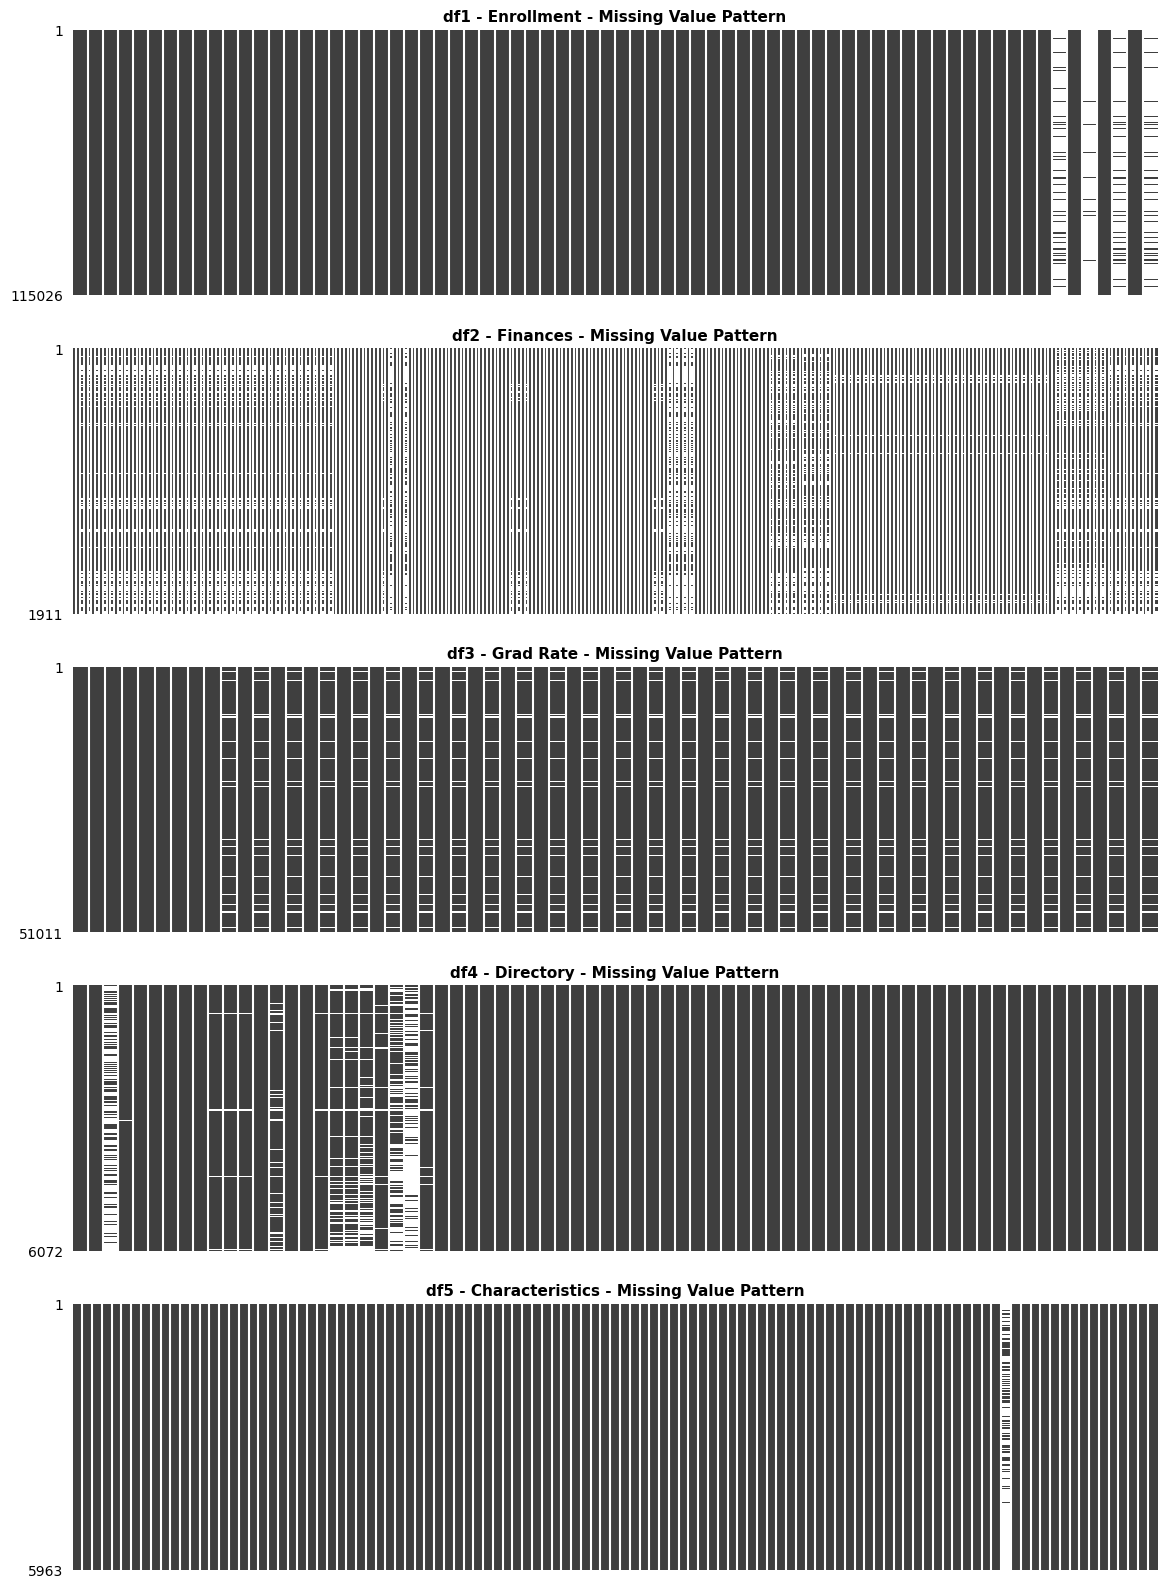

In [ ]:
# Visual: Missing value heatmap per dataset - v cool!

fig, axes = plt.subplots(5,1,figsize=(14,20))

datasets = [('df1 - Enrollment', df1), ('df2 - Finances', df2), ('df3 - Grad Rate', df3), ('df4 - Directory', df4), ('df5 - Characteristics', df5)]

for ax, (name, df) in zip(axes, datasets):
  msno.matrix(df, ax=ax, sparkline=False, fontsize=8)
  ax.set_title(f'{name} - Missing Value Pattern', fontsize=11, fontweight='bold')

plt.tight_layout
plt.show

In [ ]:
# Flag columns with missing values over 20%

threshold = 20

for name, df in [('df1 - Enrollment', df1), ('df2 - Finances', df2), ('df3 - Grad Rate', df3), ('df4 - Directory', df4), ('df5 - Characteristics', df5)]:
  missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
  flagged = missing_pct[missing_pct > threshold].sort_values(ascending=False)

  print(f"\n{'='*50}")
  print(f"  {name} - Columns Flagged (>{threshold}% missing)")
  print(f"{'='*50}")
  if flagged.empty:
    print("No columns exceed the threshold.")
  else:
    print(f"{len(flagged)} column(s) flagged:")
    display(flagged.to_frame(name='Missing %'))



  df1 - Enrollment - Columns Flagged (>20% missing)
4 column(s) flagged:


,Missing %
EFYGUAN,97.66
EFYGUTOT,89.69
EFYGUKN,89.63
EFYGUUN,88.27



  df2 - Finances - Columns Flagged (>20% missing)
62 column(s) flagged:


,Missing %
F1C131,58.14
F1C132,58.14
F1B06,58.14
F1B07,58.14
F1C121,58.14
...,...
F1N03,22.24
F1D02,22.19
F1D01,22.19
F1D05,22.19



  df3 - Grad Rate - Columns Flagged (>20% missing)
No columns exceed the threshold.

  df4 - Directory - Columns Flagged (>20% missing)
4 column(s) flagged:


,Missing %
ATHURL,71.79
IALIAS,63.88
VETURL,37.70
APPLURL,21.05



  df5 - Characteristics - Columns Flagged (>20% missing)
1 column(s) flagged:


,Missing %
DISABPCT,71.16


## Section 3: Completeness Analysis Observations

- Datasets are mostly complete
    - df1 (Enrollment): 94.93% complete (420,139 missing values out of 8,281,872 total cells)
    - df2 (Finances): 93.43% complete (36,159 missing values out of 550,368 total cells)
    - df3 (Grad Rate): 96.88% complete (105,067 missing values out of 3,366,726 total cells)
    - df4 (Directory): 96.66% complete (14,615 missing values out of 437,184 total cells)
    - df5 (Characteristics): 99.36% complete (4,243 missing values out of 661,893 total cells)


---


- Heatmaps demonstrate and reinforce findings from earlier analysis
    - df1 (Enrollment): Almost completely dark. White streaks concentrated in last few columns on the right
    - df2 (Finances): Most concerning dataset. Heavy white striping across nearly all columns. Missing values are widespread. Supports hypothesis that blanks are being used instead of zeroes
    - df3 (Grad Rate): Pattern in white stripes is consistent with findings that all 30 gender/race columns have same missing count. Uniform pattern suggests a structural reporting issue rather than data entry error
    - df4 (Directory): Missing values concentrated on the left, meaning most gaps found in first few columns. Supports earlier missing url spot check
    - df5 (Characteristics): Almost entirely dark with one column showing missing data, matching the single flagged column

## Section 4: Consistency Analysis
Checking whether data values are uniform, logical, and free of contradictions
across each IPEDS dataset. Consistency is one of the DAMA DMBOK data quality dimensions.

In [ ]:
# Check data types for unexpected formats

for name, df in [('df1 - Enrollment', df1), ('df2 - Finances', df2), ('df3 - Grad Rate', df3), ('df4 - Directory', df4), ('df5 - Characteristics', df5)]:
  print(f"\n{'='*50}")
  print(f"  {name} - Data Types")
  print (f"{'='*50}")
  print(df.dtypes)


  df1 - Enrollment - Data Types
UNITID        int64
EFFYALEV      int64
EFFYLEV       int64
LSTUDY        int64
XEYTOTLT     object
             ...   
EFYGUAN     float64
XEFYGUTO     object
EFYGUTOT    float64
XEFYGUKN     object
EFYGUKN     float64
Length: 72, dtype: object

  df2 - Finances - Data Types
UNITID      int64
XF1A01     object
F1A01     float64
XF1A31     object
F1A31     float64
           ...   
F1N05     float64
XF1N06     object
F1N06     float64
XF1N07     object
F1N07     float64
Length: 288, dtype: object

  df3 - Grad Rate - Data Types
UNITID        int64
GRTYPE        int64
CHRTSTAT      int64
SECTION       int64
COHORT        int64
             ...   
GRNRALT     float64
XGRNRALM     object
GRNRALM     float64
XGRNRALW     object
GRNRALW     float64
Length: 66, dtype: object

  df4 - Directory - Data Types
UNITID        int64
INSTNM       object
IALIAS       object
ADDR         object
CITY         object
             ...   
CNGDSTCD      int64
LONGITUD    flo

In [ ]:
# Check for negative values in numeric columns

for name, df in [('df1 - Enrollment', df1), ('df2 - Finances', df2), ('df3 - Grad Rate', df3), ('df4 - Directory', df4), ('df5 - Characteristics', df5)]:
  numeric_cols = df.select_dtypes(include='number').columns
  negatives = {col: (df[col] < 0).sum() for col in numeric_cols if (df[col] < 0).sum() > 0}

  print(f"\n{'='*50}")
  print(f"  {name} - Columns with Negative Values")
  print (f"{'='*50}")
  if not negatives:
    print("No negative values found.")
  else:
    for col, count in negatives.items():
      print(f"  {col}: {count:,} negative values")


  df1 - Enrollment - Columns with Negative Values
  EFFYLEV: 101,523 negative values

  df2 - Finances - Columns with Negative Values
  F1A04: 4 negative values
  F1A20: 2 negative values
  F1A14: 21 negative values
  F1A15: 12 negative values
  F1A17: 716 negative values
  F1A18: 147 negative values
  F1D03: 232 negative values
  F1D04: 166 negative values
  F1D05: 353 negative values
  F1D06: 147 negative values
  F1B26: 1 negative values
  F1B08: 1 negative values
  F1B16: 5 negative values
  F1B17: 12 negative values
  F1B18: 1 negative values
  F1B20: 3 negative values
  F1B21: 2 negative values
  F1B23: 22 negative values
  F1C141: 165 negative values
  F1C193: 20 negative values
  F1C19DP: 1 negative values
  F1C19IN: 1 negative values
  F1C19OT: 1 negative values
  F1M01: 348 negative values
  F1M02: 36 negative values
  F1M03: 23 negative values
  F1M04: 5 negative values
  F1M05: 692 negative values
  F1M06: 164 negative values
  F1M07: 23 negative values
  F1M08: 4 negative

In [ ]:
# Investigating negative values

# df2-Finances, other non-current assets, F1A04

# Filter df2 for rows where 'F1A04' is negative
filtered_df2 = df2[df2['F1A04'] < 0]

# Merge the filtered df2 with df4 to get institution names
result = filtered_df2[['UNITID', 'F1A04']].merge(df4[['UNITID', 'INSTNM']], on='UNITID')

# Display the relevant columns
display(result[['INSTNM', 'F1A04']])



,INSTNM,F1A04
0,University of Illinois Springfield,-877152.00
1,Hagerstown Community College,-107704121.00
2,Clackamas Community College,-55980147.00
3,Carolinas College of Health Sciences,-2754063.00


In [ ]:
# Investigating negative values

# df2-Finances, unrestricted scholarships and grants, F1E06

# Filter df2 for rows where 'F1E06' is negative
filtered2_df2 = df2[df2['F1E06'] < 0]

#Merge filtered df2 with df4 to get institution names
result2 = filtered2_df2[['UNITID', 'F1E06']].merge(df4[['UNITID', 'INSTNM']], on='UNITID')

# Display the relevant columns
display(result2[['INSTNM', 'F1E06']])

,INSTNM,F1E06
0,United States Merchant Marine Academy,-404767.00


In [ ]:
# Check for duplicate UNITID rows within each dataset

for name, df in [('df1 - Enrollment', df1), ('df2 - Finances', df2), ('df3 - Grad Rate', df3), ('df4 - Directory', df4), ('df5 - Characteristics', df5)]:
  if 'UNITID' in df.columns:
    dupes = df.duplicated(subset='UNITID').sum()
    print(f"{name} - Duplicate UNITIDs: {dupes:,}")
  else:
    print(f"{name} - No UNITID found")

df1 - Enrollment - Duplicate UNITIDs: 109,165
df2 - Finances - Duplicate UNITIDs: 0
df3 - Grad Rate - Duplicate UNITIDs: 47,327
df4 - Directory - Duplicate UNITIDs: 0
df5 - Characteristics - Duplicate UNITIDs: 0


In [ ]:
# Check percentage columns are between 0 and 100

for name, df in [('df1 - Enrollment', df1), ('df2 - Finances', df2),
                  ('df3 - Grad Rate', df3), ('df4 - Directory', df4),
                  ('df5 - Characteristics', df5)]:

    pct_cols = [col for col in df.columns if 'PCT' in col.upper() or 'RATE' in col.upper()]

    print(f"\n{'='*50}")
    print(f"  {name} — Percentage Column Consistency Check")
    print(f"{'='*50}")

    if not pct_cols:
        print("No percentage/rate columns found.")
    else:
        for col in pct_cols:
            numeric = pd.to_numeric(df[col], errors='coerce')
            out_of_range = numeric[(numeric < 0) | (numeric > 100)].count()
            if out_of_range > 0:
                print(f"  {col}: {out_of_range:,} values outside 0-100 range")
            else:
                print(f"  {col}: OK")


  df1 - Enrollment — Percentage Column Consistency Check
No percentage/rate columns found.

  df2 - Finances — Percentage Column Consistency Check
No percentage/rate columns found.

  df3 - Grad Rate — Percentage Column Consistency Check
No percentage/rate columns found.

  df4 - Directory — Percentage Column Consistency Check
No percentage/rate columns found.

  df5 - Characteristics — Percentage Column Consistency Check
  DISABPCT: OK


In [ ]:
# Check df2 for columns that look numeric but are stored as text
print("df2 - Finances — Possible Numeric Columns Stored as Text\n")

for col in df2.columns:
    if df2[col].dtype == 'object':  # object means text in pandas
        # Try converting to numeric
        converted = pd.to_numeric(df2[col], errors='coerce')
        non_null_original = df2[col].dropna().shape[0]
        successful_convert = converted.dropna().shape[0]

        if successful_convert > 0:
            print(f"  {col}: stored as text but {successful_convert:,} values are numeric")

df2 - Finances — Possible Numeric Columns Stored as Text



## Section 4: Consistency Analysis Observations

#### Negative Values
Important Context: Negative values in IPEDS cannot be treated as errors without consulting data dictionary. IPEDS uses negative numbers as coding conventions, not always as true negative values.

*   df1 (Enrollment): EFFYLEV has 101,523 negatives (88% of rows). Every negative equals -2, which the dictionary for the dataset defines as "Not applicable, undergraduate detail"
*   df2 (Finances): 41 columns contain negative values. These are worth investigating. For example:
    - Hagerstown Community College has an "other non-current assets" value of -107,704,121 USD. This is a large negative for a community college
    - F1D05 has 353 negative values. This is an automatic balancing line and is likely ok
    - F1E06 (Institutional grants/scholarships from unrestricted sources) returned only 1 negative value from the US Merchant Marine Academy: -404,767 USD. Due to its connection with the federal government, this institution likely has reporting standards that differ from standard


*   df3 (Grad Rate): No negative values found
*   df4 (Directory): 37 columns contain negative values. These are likely due to 2 factors:
    - The dictionary for this dataset includes the coding convention:
      - -1: Not reported
      - -2: Not applicable
      - -3: Not available
      - -9: Not active
    - There are 6,065 negative longitude values and 1 negative latitute value


*   df5 (Characteristics): 95 columns contain negative values. This dataset uses -2 for "Not applicable". This convention is widely used throughout the dataset


---


#### Duplicate UNITIDs
- df1 (Enrollment): 109,165 duplicate UNITIDs.
  Multiple rows per institution represent different race/gender/
  student level combinations
- df2 (Finances): 0 duplicates. One financial report per institution
- df3 (Grad Rate): 47,327 duplicate UNITIDs.
  Multiple rows represent race/gender graduation cohorts
- df4 (Directory): 0 duplicates. One row per institution
- df5 (Characteristics): 0 duplicates. One row per institution


---


#### Percentage Columns
- Only one percentage column found across all 5 datasets (DISABPCT in df5)
- DISABPCT passed the 0-100 range check with no out of range values


---


#### Numeric Columns Stored as Text Check (df2 - Finances)
- No numeric values found stored as text in df2
- Widespread missing values in df2 are confirmed as truly blank fields,
  not a formatting issue
- The volume of unreported financial fields remains a concern and
  requires further investigation


---


#### Encoding Issue
- df4 (Directory) UNITID column contained Byte Order Mark characters
  displayed as ï»¿UNITID when loaded with latin-1 encoding
- Fixed by changing encoding to utf-8-sig








## Section 5: Accuracy Analysis
Measuring whether data values are correct and reflect reality.
Accuracy is one of the DAMA DMBOK quality dimensions. Note: IPEDS is
self-reported by institutions. Accuracy is assessed through range
checks, outlier detection, and cross-dataset validation.

In [ ]:
# Check for outliers in df1 - Enrollment data

enrollment_cols = [col for col in df1.columns if 'EFYTOT' in col.upper()]
print("Enrollment total columns found:", enrollment_cols)

for col in enrollment_cols:
  numeric = pd.to_numeric(df1[col], errors='coerce')
  print(f"\n{col} Statistics:")
  print(numeric.describe())
  print(f"Values over 100,000: {(numeric > 100000).sum()}")

Enrollment total columns found: ['EFYTOTLT', 'EFYTOTLM', 'EFYTOTLW']

EFYTOTLT Statistics:
count   115026.00
mean      1839.35
std       5681.70
min          1.00
25%         76.00
50%        310.00
75%       1355.00
max     282150.00
Name: EFYTOTLT, dtype: float64
Values over 100,000: 41

EFYTOTLM Statistics:
count   115026.00
mean       775.89
std       2475.51
min          0.00
25%         14.00
50%        101.00
75%        558.00
max     114481.00
Name: EFYTOTLM, dtype: float64
Values over 100,000: 2

EFYTOTLW Statistics:
count   115026.00
mean      1063.47
std       3299.76
min          0.00
25%         44.00
50%        192.00
75%        796.00
max     167669.00
Name: EFYTOTLW, dtype: float64
Values over 100,000: 17


In [ ]:
# Researching enrollment outlier results

# Show top 10 unique institutions by their maximum total enrollment
top_unique = df1.groupby('UNITID')['EFYTOTLT'].max().reset_index()
top_unique = top_unique.sort_values('EFYTOTLT', ascending=False).head(10)

# Cross reference with df4 for institution names
top_unique_names = top_unique.merge(df4[['UNITID', 'INSTNM', 'STABBR']], on='UNITID', how='left')
print("Top 10 Unique Institutions by Total Enrollment:")
display(top_unique_names)

Top 10 Unique Institutions by Total Enrollment:


,UNITID,EFYTOTLT,INSTNM,STABBR
0,433387,282150,Western Governors University,UT
1,183026,255134,Southern New Hampshire University,NH
2,150987,178903,Ivy Tech Community College,IN
3,104717,170467,Grand Canyon University,AZ
4,484613,156956,University of Phoenix-Arizona,AZ
5,232557,143337,Liberty University,VA
6,227182,107793,Lone Star College System,TX
7,224615,104064,Dallas College,TX
8,483124,98316,Arizona State University Digital Immersion,AZ
9,449339,95158,American Public University System,WV


In [ ]:
# Check for outliers in df2 - Finances data
# F1A06: Total Assets, F1A13: Total Liabilities, F1D01: Total Revenues, F1D02: Total Expenses

finance_cols = ['F1A06', 'F1A13', 'F1D01', 'F1D02']

for col in finance_cols:
    if col in df2.columns:
        numeric = pd.to_numeric(df2[col], errors='coerce')
        print(f"\n{col} Statistics:")
        print(numeric.describe())
    else:
        print(f"{col} not found in df2")


F1A06 Statistics:
count           1486.00
mean       749040726.03
std       4004170671.74
min                0.00
25%         72948181.00
50%        170198393.00
75%        454276350.25
max     104112000000.00
Name: F1A06, dtype: float64

F1A13 Statistics:
count          1486.00
mean      415092832.04
std      2751090647.12
min               0.00
25%        26473838.00
50%        68543973.00
75%       250441153.75
max     93219887000.00
Name: F1A13, dtype: float64

F1D01 Statistics:
count          1487.00
mean      369882360.29
std      1883839521.87
min         4245564.00
25%        41619204.00
50%        90478197.00
75%       226885157.00
max     63528005000.00
Name: F1D01, dtype: float64

F1D02 Statistics:
count          1487.00
mean      333793328.58
std      1707711005.71
min         3996146.00
25%        37048523.50
50%        79613876.00
75%       208673471.50
max     58038557000.00
Name: F1D02, dtype: float64


In [ ]:
# Researching finances outlier results
# Find institutions with the largest total assets
top_assets = df2[['UNITID', 'F1A06']].sort_values('F1A06', ascending=False).head(5)
top_assets = top_assets.merge(df4[['UNITID', 'INSTNM']], on='UNITID', how='left')
print("Top 5 Institutions by Total Assets:")
display(top_assets)

# Find institutions with zero total assets
zero_assets = df2[df2['F1A06'] == 0][['UNITID', 'F1A06']]
zero_assets = zero_assets.merge(df4[['UNITID', 'INSTNM']], on='UNITID', how='left')
print(f"\nInstitutions with Zero Total Assets: {len(zero_assets)}")
display(zero_assets)


Top 5 Institutions by Total Assets:


,UNITID,F1A06,INSTNM
0,124557,104112000000.00,University of California-System Administration...
1,229090,92193294888.00,The University of Texas System Office
2,170976,33755911000.00,University of Michigan-Ann Arbor
3,204796,22436262359.00,Ohio State University-Main Campus
4,236948,18488640118.00,University of Washington-Seattle Campus



Institutions with Zero Total Assets: 1


,UNITID,F1A06,INSTNM
0,155140,0.00,Haskell Indian Nations University


In [ ]:
# Cross validate UNITID counts across datasets

print("Unique Institutions Count by Dataset\n")

for name, df in [('df1 - Enrollment', df1), ('df2 - Finances', df2), ('df3 - Grad Rate', df3), ('df4 - Directory', df4), ('df5 - Characteristics', df5)]:
  if 'UNITID' in df.columns:
    unique = df['UNITID'].nunique()
    print(f"{name}: {unique:,} unique institutions")

Unique Institutions Count by Dataset

df1 - Enrollment: 5,861 unique institutions
df2 - Finances: 1,911 unique institutions
df3 - Grad Rate: 3,684 unique institutions
df4 - Directory: 6,072 unique institutions
df5 - Characteristics: 5,963 unique institutions


In [ ]:
# Researching cross validation of UNITIDs to see if they match the UNITIDs in the directory df4

print("UNITID Match Rate Against df4 Directory\n")

df4_ids = set(df4['UNITID'].unique())

for name, df in [('df1 - Enrollment', df1), ('df2 - Finances', df2),
                  ('df3 - Grad Rate', df3), ('df5 - Characteristics', df5)]:
    if 'UNITID' in df.columns:
        dataset_ids = set(df['UNITID'].unique())
        matched = dataset_ids.intersection(df4_ids)
        unmatched = dataset_ids.difference(df4_ids)

        print(f"{name}:")
        print(f"  Total unique UNITIDs: {len(dataset_ids):,}")
        print(f"  Matched to df4: {len(matched):,}")
        print(f"  NOT in df4: {len(unmatched):,}")
        if unmatched:
            print(f"  Unmatched UNITIDs: {unmatched}")
        print()

UNITID Match Rate Against df4 Directory

df1 - Enrollment:
  Total unique UNITIDs: 5,861
  Matched to df4: 5,861
  NOT in df4: 0

df2 - Finances:
  Total unique UNITIDs: 1,911
  Matched to df4: 1,911
  NOT in df4: 0

df3 - Grad Rate:
  Total unique UNITIDs: 3,684
  Matched to df4: 3,684
  NOT in df4: 0

df5 - Characteristics:
  Total unique UNITIDs: 5,963
  Matched to df4: 5,963
  NOT in df4: 0



In [ ]:
# Check accuracy of geographic data in df4 - Directory

# US institutions should have long between -180 and -60, lat between 15 and 75

print("df4 - Geographic Coordinate Accuracy Check\n")

invalid_long = df4[(df4['LONGITUD'] > 0) & (df4['LONGITUD'] != -999)]['LONGITUD'].count()
invalid_lat = df4[(df4['LATITUDE'] < 15) & (df4['LATITUDE'] > 0)]['LATITUDE'].count()

print(f"Institutions with positive longitude (unexpected for US): {invalid_long:,}")
print(f"Institutions with latitude below 15 (unexpected for US): {invalid_lat:,}")

# Show any suspicious coordinates

suspicious = df4[(df4['LONGITUD'] > 0) & (df4['LONGITUD'] != -999)][['INSTNM', 'LONGITUD', 'LATITUDE', 'STABBR']]
if not suspicious.empty:
    print("\nInstitutions with unexpected coordinates:")
    display(suspicious)

df4 - Geographic Coordinate Accuracy Check

Institutions with positive longitude (unexpected for US): 7
Institutions with latitude below 15 (unexpected for US): 6

Institutions with unexpected coordinates:


,INSTNM,LONGITUD,LATITUDE,STABBR
3562,Guam Community College,144.81,13.44,GU
3563,University of Guam,144.80,13.43,GU
3564,Northern Marianas College,145.72,15.15,MP
3630,College of Micronesia-FSM,158.16,6.91,FM
3631,Palau Community College,134.47,7.34,PW
3848,College of the Marshall Islands,171.38,7.10,MH
4291,Pacific Islands University,144.84,13.47,GU


## Section 5: Accuracy Analysis Observations

#### Outliers
*   df1 (Enrollment)
    - Of the top 10 unique institutions by total enrollment, 8 are primarily or fully online
    - Any analysis using raw enrollment figures should differentiate between online and residential institutions
*   df2 (Finance)
    - F1A06 (Total Assets) has a very large range. Top institutions are system-level universities such as UC System: 104B USD and UT System: 92B USD. These numbers make sense
    - Haskell Indian Nations University has Total Assets of 0 USD. This is a federally operated institution and likely has reporting structures that differ from standard
    - Note regarding Completeness Gap: df2 dataset contains 1,911 rows, but only 1,486 institutions report key financial totals (Total Assets, Total Liabilities, Total Revenue, Total Expenses)


---


#### Unique Institution Counts — Cross Dataset Validation
Baseline: df4 (Directory) contains 6,072 unique institutions. Computed number of unique UNITIDs in each dataset and validated that every unique UNITID matches back to Directory

*   df1 (Enrollment): 5,861 / 100% match
*   df2 (Finances): 1,911 / 100% match
*   df3 (Grad Rate): 3,684 / 100% match
*   df5 (Characteristics): 5,963 / 100% match

Findings:


*   All 4 datasets had a 100% UNITID match with the df4 (Directory) dataset. They did not contain any institutions not found in the Directory
*   Counts for both df1 and df5 are large. Most institutions filled out the surveys
*   Count for df3 is smaller, but to be expected. Not all institutions are degree-granting
*   Count for df2 is significantly smaller than the baseline. This analysis only includes financial data for public institutions. Private institutions submit different financial data not included in this dataset. Any analysis should clearly state "Public Institutions Only"


---


#### Geographic Coordinates
Coordinates are found in df4 (Directory)

Findings:
*   7 institutions with geographic coordinates outside of the continental US
*   All are legitimate US-affliated institutions located in the Pacific Islands
*   Any mapping or geospatial analysis should account for these institutions
















## Section 6: Timeliness Analysis
Measuring whether data is current, complete for the expected time
period, and free of outdated records. Timeliness is one of the
DAMA DMBOK data quality dimensions.

In [ ]:
# Check for closed institutions in the directory

# DEATHYR contains year (positive value) institution closed and was removed from
# IPEDS
# Negative value (such as -2) is a coding convention and, in this case,
# means institution is not closed (ie still open)

print("df4 (Directory) - Institution Status Check\n")

closed = df4[df4['DEATHYR'] > 0]
open_inst = df4[df4['DEATHYR'] <= 0]

print(f"Total institutions in directory: {len(df4):,}")
print(f"Currently open institutions: {len(open_inst):,}")
print(f"Closed institutions: {len(closed):,}")

if not closed.empty:
  print(f"\nClosed institutions by year:")
  display(closed['DEATHYR'].value_counts().sort_index())




df4 (Directory) - Institution Status Check

Total institutions in directory: 6,072
Currently open institutions: 6,001
Closed institutions: 71

Closed institutions by year:


,count
DEATHYR,
2024,69
2025,2


In [ ]:
# Which institutions are closing in 2025

future_closed = df4[df4['DEATHYR'] == 2025][['UNITID', 'INSTNM', 'CITY', 'STABBR', 'DEATHYR']]
print("Institutions with 2025 closure date:")
display(future_closed)

Institutions with 2025 closure date:


,UNITID,INSTNM,CITY,STABBR,DEATHYR
4806,456968,Health And Style Institute,Greensboro,NC,2025
5741,493831,Midwest Barber College,Topeka,KS,2025


In [ ]:
# Check if closed institutions are still reporting data

closed_ids = set(closed['UNITID'].unique())

print("Are closed institutions still reporting data?\n")

for name, df in [('df1 - Enrollment', df1), ('df2 - Finances', df2), ('df3 - Grad Rate', df3), ('df4 - Directory', df4), ('df5 - Characteristics', df5)]:
  if 'UNITID' in df.columns:
    dataset_ids = set(df['UNITID'].unique())
    closed_reporting = dataset_ids.intersection(closed_ids)
    print(f"{name}: {len(closed_reporting):,} closed institutions still reporting data")

Are closed institutions still reporting data?

df1 - Enrollment: 14 closed institutions still reporting data
df2 - Finances: 0 closed institutions still reporting data
df3 - Grad Rate: 3 closed institutions still reporting data
df4 - Directory: 71 closed institutions still reporting data
df5 - Characteristics: 17 closed institutions still reporting data


In [ ]:
# Which closed institutions are still reporting data

closed_ids = set(closed['UNITID'].unique())

for name, df in [('df1 - Enrollment', df1), ('df3 - Grad Rate', df3),
                  ('df5 - Characteristics', df5)]:
    if 'UNITID' in df.columns:
        dataset_ids = set(df['UNITID'].unique())
        closed_reporting = dataset_ids.intersection(closed_ids)

        if closed_reporting:
            details = df4[df4['UNITID'].isin(closed_reporting)][['UNITID', 'INSTNM',
                                                                   'CITY', 'STABBR',
                                                                   'DEATHYR']]
            print(f"\n{name} — Closed institutions still reporting:")
            display(details)


df1 - Enrollment — Closed institutions still reporting:


,UNITID,INSTNM,CITY,STABBR,DEATHYR
1870,183035,New Hampshire Institute for Therapeutic Arts,Nashua,NH,2024
2102,192004,Jamestown Business College,Jamestown,NY,2024
2147,193894,New York Theological Seminary,New York,NY,2024
3416,235501,International Air and Hospitality Academy,Vancouver,WA,2024
3705,260813,Platt College-Aurora,Greenwood Village,CO,2024
3719,262369,Adrian's Beauty College of Turlock,Turlock,CA,2024
3739,364760,Bell Mar Beauty College,Cicero,IL,2024
3847,376677,Queen City College,Clarksville,TN,2024
4582,449445,Valley College of Medical Careers,West Hills,CA,2024
4590,449533,Pensacola School of Massage Therapy & Health C...,Pensacola,FL,2024



df3 - Grad Rate — Closed institutions still reporting:


,UNITID,INSTNM,CITY,STABBR,DEATHYR
2102,192004,Jamestown Business College,Jamestown,NY,2024
4786,456153,MediaTech Institute-Houston,Houston,TX,2024
4806,456968,Health And Style Institute,Greensboro,NC,2025



df5 - Characteristics — Closed institutions still reporting:


,UNITID,INSTNM,CITY,STABBR,DEATHYR
1870,183035,New Hampshire Institute for Therapeutic Arts,Nashua,NH,2024
2102,192004,Jamestown Business College,Jamestown,NY,2024
2147,193894,New York Theological Seminary,New York,NY,2024
3416,235501,International Air and Hospitality Academy,Vancouver,WA,2024
3705,260813,Platt College-Aurora,Greenwood Village,CO,2024
3719,262369,Adrian's Beauty College of Turlock,Turlock,CA,2024
3739,364760,Bell Mar Beauty College,Cicero,IL,2024
3779,367884,Hodges University,Fort Myers,FL,2024
3847,376677,Queen City College,Clarksville,TN,2024
4582,449445,Valley College of Medical Careers,West Hills,CA,2024


In [ ]:
# Find year covereage in df1 enrollment data

year_cols = [col for col in df1.columns if 'YR' in col.upper() or 'YEAR' in col. upper()]
print("Year-related columns in df1 (Enrollment):")
print(year_cols)

Year-related columns in df1 (Enrollment):
[]


In [ ]:
# Check reporting periods in df2 financial data

# Look for year or period columns in df2
year_cols_df2 = [col for col in df2.columns if 'YR' in col.upper()
                  or 'YEAR' in col.upper() or 'PERIOD' in col.upper()]
print("Year-related columns in df2 (Finances):")
print(year_cols_df2)


Year-related columns in df2 (Finances):
[]


In [ ]:
# Look for outdated addresses

# Look for any institutions in territories or states
# that seem inconsistent with their address data
print("df4 - Checking for missing address information\n")

address_cols = ['ADDR', 'CITY', 'STABBR', 'ZIP']
available_addr = [col for col in address_cols if col in df4.columns]

for col in available_addr:
    missing = df4[col].isnull().sum()
    print(f"{col}: {missing:,} missing values")

# Check for any institutions missing state abbreviation
if 'STABBR' in df4.columns:
    print(f"\nUnique state abbreviations: {df4['STABBR'].nunique()}")
    print(df4['STABBR'].value_counts().head(10))

df4 - Checking for missing address information

ADDR: 11 missing values
CITY: 0 missing values
STABBR: 0 missing values
ZIP: 0 missing values

Unique state abbreviations: 59
STABBR
CA    668
NY    408
TX    403
FL    336
PA    315
OH    273
IL    240
NC    163
MI    160
NJ    149
Name: count, dtype: int64


In [ ]:
# Which institutions are missing addresses

missing_addr = df4[df4['ADDR'].isnull()][['UNITID', 'INSTNM', 'CITY', 'STABBR', 'ZIP']]
print("Institutions missing street address:")
display(missing_addr)

Institutions missing street address:


,UNITID,INSTNM,CITY,STABBR,ZIP
10,100858,Auburn University,Auburn,AL,36849
1359,163286,University of Maryland-College Park,College Park,MD,20742
1486,168148,Tufts University,Medford,MA,02155-5555
1554,171100,Michigan State University,East Lansing,MI,48824-1046
2142,193654,The New School,New York,NY,10011
2469,203128,Hiram College,Hiram,OH,44234-0067
3093,222178,Abilene Christian University,Abilene,TX,79699
3384,234085,Virginia Military Institute,Lexington,VA,24450-0304
3633,243744,Stanford University,Stanford,CA,94305
4313,440916,Southern University Law Center,Baton Rouge,LA,70813


## Section 6: Timeliness Analysis Observations

#### Institution Status
Total institutions in df4 (Directory): 6,072
- Currently open institutions: 6,001
- Closed institutions: 71
  - 69 closed in 2024
  - 2 flagged for 2025 closure (Health And Style Institute, Greensboro NC and Midwest Barber College, Topeka KS)


---


#### Closed Instiutions Still Reporting Data
Datasets and the number of closed institutions reporting:
- df1 (Enrollment): 14
- df2 (Finances): 0
- df3 (Grad Rate): 3
- df5 (Characteristics): 17

Closed institutions appearing across datasets df1, df2, and df3:
- Jamestown Business College, Jamestown, NY
- MediaTech Institute-Houston, Houston, TX
- Health and Style Institute, Greensboro, NC

Governance finding: Closed institutions reporting partial year data is expected with closure occurs during the year. Any analysis should include a DEATHYR filter on df4 (Directory) to identify closed institutions.


---


#### Reporting Year Documentation
No internal year columns exist in df1 (Enrollment) or df2 (Finances). The reporting year is conveyed only through filenames:
- df1 (Enrollment): effy2024.csv
- df2 (Finances): f2324.csv

Governance finding: If files are renamed, reorganized, or combined with data from other years, there is no internal indicator of which year coincides with with which data. A best practice would be to add a REPORT_YEAR column to ensure datasets are self-documenting and year-safe for longitudinal analysis.


---


#### Address Completeness
Overall address data in d4 (Directory) is highly complete:
- Street address (ADDR): 11 missing (0.2%)
- City: 0 missing (100% complete)
- State: 0 missing (100% complete)
- ZIP: 0 missing (100% complete)

Governance finding: 59 unique state abbreviations correctly account for 50 states plus Washington DC, US territories, and Freely Associated States. The 11 missing street addresses include large, well-known universities (for example, Auburn University) and are likely data entry oversights rather than unknowns. These are low-risk ommissions, but should be flagged for correction in next data collection cycle.


## Section 7: Uniqueness Analysis
Measuring whether records are duplicated within and across datasets.
Uniqueness is one of the DAMA DMBOK data quality dimensions.

In [ ]:
# Check for fully duplicated rows within each dataset

print("Fully Duplicated Rows by Dataset\n")

for name, df in [('df1 - Enrollment', df1), ('df2 - Finances', df2), ('df3 - Grad Rate', df3), ('df4 - Directory', df4), ('df5 - Characteristics', df5)]:
  full_dupes = df.duplicated().sum()
  print(f"{name}: {full_dupes:,} fully duplicated rows")

Fully Duplicated Rows by Dataset

df1 - Enrollment: 0 fully duplicated rows
df2 - Finances: 0 fully duplicated rows
df3 - Grad Rate: 0 fully duplicated rows
df4 - Directory: 0 fully duplicated rows
df5 - Characteristics: 0 fully duplicated rows


In [ ]:
# Check for duplicate institution names in df4 (Directory)

print("df4 (Directory) - Duplicate Institution Names \n")

name_counts = df4['INSTNM'].value_counts()
duplicate_names = name_counts[name_counts > 1]

print(f"Institution names appearing more than once: {len(duplicate_names):,}")
print(f"\nTop 20 most duplicated names:")
display(duplicate_names.head(20))

df4 (Directory) - Duplicate Institution Names 

Institution names appearing more than once: 72

Top 20 most duplicated names:


,count
INSTNM,
Cortiva Institute,6
Academy of Beauty Professionals,4
Columbia College,4
Brittany Beauty Academy,3
ATA College,3
The Salon Professional Academy,3
Innovate Salon Academy,3
Interactive College of Technology,3
Eastern Suffolk BOCES,3


In [ ]:
# Check for duplicate EIN numbers in df4 (Directory) - Federal Tax ID Number

print("df4 (Directory) - Duplicate EIN Analysis\n")

# filter out the coding conventions that result in negative number in EIN column

valid_ein = df4[df4['EIN'] > 0]

# Count valid EINs
ein_counts = valid_ein['EIN'].value_counts()
duplicate_eins = ein_counts[ein_counts > 1]

print(f"Total institutions with valid EINs: {len(valid_ein):,}")
print(f"EINs appearing more than once: {len(duplicate_eins):,}")
print(f"\nTop 10 most shared EINs:")
display(duplicate_eins.head(10))

df4 (Directory) - Duplicate EIN Analysis

Total institutions with valid EINs: 5,994
EINs appearing more than once: 401

Top 10 most shared EINs:


,count
EIN,
208939053,69
861846791,40
411687554,30
146013200,29
246000376,22
461749258,20
431537880,20
611140524,20
520500740,17


In [ ]:
# Investigate shared EINs

print("Institutions sharing EINS (sample)\n")

top_shared_eins = duplicate_eins.head(5).index.tolist()

for ein in top_shared_eins:
  institutions = df4[df4['EIN'] == ein] [['UNITID', 'INSTNM', 'CITY', 'STABBR', 'EIN']]

  print(f"\nEIN: {ein}")
  display(institutions)

Institutions sharing EINS (sample)


EIN: 208939053


,UNITID,INSTNM,CITY,STABBR,EIN
65,103741,Empire Beauty School-Tucson,Tucson,AZ,208939053
78,104443,Empire Beauty School-Chandler,Chandler,AZ,208939053
546,128337,Empire Beauty School-Thornton,Thornton,CO,208939053
1231,157614,Empire Beauty School-Chenoweth,Louisville,KY,208939053
1232,157650,Empire Beauty School-Elizabethtown,Elizabethtown,KY,208939053
...,...,...,...,...,...
5415,486691,Empire Beauty School-Northlake,Atlanta,GA,208939053
5613,491136,Empire Beauty School-Tampa,Tampa,FL,208939053
5614,491145,Empire Beauty School-Lakeland,Lakeland,FL,208939053
5823,495518,Empire Beauty School-Newport News,Newport News,VA,208939053



EIN: 861846791


,UNITID,INSTNM,CITY,STABBR,EIN
1571,171988,Ross Medical Education Center-Lansing,Lansing,MI,861846791
1572,171997,Ross Medical Education Center-Warren,Warren,MI,861846791
1573,172015,Ross Medical Education Center-Flint,Flint,MI,861846791
2472,203234,Ross Medical Education Center-Cincinnati,Cincinnati,OH,861846791
3673,247409,Ross Medical Education Center-Saginaw,Saginaw,MI,861846791
3710,261676,Ross Medical Education Center-Brighton,Brighton,MI,861846791
3711,261685,Ross Medical Education Center-Ann Arbor,Ann Arbor,MI,861846791
3723,363013,Ross Medical Education Center-Port Huron,Port Huron,MI,861846791
3753,365824,Ross Medical Education Center-Roosevelt Park,Roosevelt Park,MI,861846791
3754,365833,Ross Medical Education Center-Kentwood,Kentwood,MI,861846791



EIN: 411687554


,UNITID,INSTNM,CITY,STABBR,EIN
1594,172954,Anoka Technical College,Anoka,MN,411687554
1595,172963,Anoka-Ramsey Community College,Coon Rapids,MN,411687554
1597,173063,Riverland Community College,Austin,MN,411687554
1598,173115,Northwest Technical College,Bemidji,MN,411687554
1599,173124,Bemidji State University,Bemidji,MN,411687554
1606,173416,Dakota County Technical College,Rosemount,MN,411687554
1608,173461,Lake Superior College,Duluth,MN,411687554
1610,173638,Minnesota West Community and Technical College,Granite Falls,MN,411687554
1614,173708,Hennepin Technical College,Brooklyn Park,MN,411687554
1615,173735,Minnesota North College,Hibbing,MN,411687554



EIN: 146013200


,UNITID,INSTNM,CITY,STABBR,EIN
2199,195827,SUNY-System Office,Albany,NY,146013200
2201,196006,SUNY College of Technology at Alfred,Alfred,NY,146013200
2202,196015,SUNY College of Technology at Canton,Canton,NY,146013200
2203,196024,SUNY College of Technology at Delhi,Delhi,NY,146013200
2204,196033,SUNY College of Agriculture and Technology at ...,Cobleskill,NY,146013200
2205,196042,Farmingdale State College,Farmingdale,NY,146013200
2206,196051,SUNY Morrisville,Morrisville,NY,146013200
2207,196060,University at Albany,Albany,NY,146013200
2208,196079,Binghamton University,Vestal,NY,146013200
2209,196088,University at Buffalo,Buffalo,NY,146013200



EIN: 246000376


,UNITID,INSTNM,CITY,STABBR,EIN
2802,214591,Pennsylvania State University-Penn State Erie-...,Erie,PA,246000376
2803,214607,Pennsylvania State University-Penn State Great...,Malvern,PA,246000376
2804,214625,Pennsylvania State University-Penn State New K...,New Kensington,PA,246000376
2805,214634,Pennsylvania State University-Penn State Shenango,Sharon,PA,246000376
2806,214643,Pennsylvania State University-Penn State Wilke...,Dallas,PA,246000376
2807,214652,Pennsylvania State University-Penn State Scranton,Dunmore,PA,246000376
2809,214670,Pennsylvania State University-Penn State Lehig...,Center Valley,PA,246000376
2810,214689,Pennsylvania State University-Penn State Altoona,Altoona,PA,246000376
2811,214698,Pennsylvania State University-Penn State Beaver,Monaca,PA,246000376
2812,214704,Pennsylvania State University-Penn State Berks,Reading,PA,246000376


In [ ]:
# Check for duplicate OPEID numbers in df4 (Directory) - Federal Financial Aid Number

print("df4 (Directory) - Duplicate OPEID Analysis\n")

# filter out the coding conventions that result in negative number in OPEID column

valid_opeid = df4[df4['OPEID'] > 0]

# Count valid OPEIDs

opeid_counts = valid_opeid['OPEID'].value_counts()
duplicate_opeids = opeid_counts[opeid_counts > 1]

print(f"Total institutions with valid OPEIDs: {len(valid_opeid):,}")
print(f"OPEIDs appearing more than once: {len(duplicate_opeids):,}")

if not duplicate_opeids.empty:
  print(f"\nTop 10 most shared OPEIDs:")
  display(duplicate_opeids.head(10))


df4 (Directory) - Duplicate OPEID Analysis

Total institutions with valid OPEIDs: 6,034
OPEIDs appearing more than once: 39

Top 10 most shared OPEIDs:


,count
OPEID,
202500.00,3
394000.00,2
336800.00,2
240100.00,2
638500.00,2
127200.00,2
145900.00,2
363600.00,2
301000.00,2


In [ ]:
# Investigate shared OPEIDs

top_opeids = duplicate_opeids.head(5).index.tolist()

for opeid in top_opeids:
  institutions = df4[df4['OPEID'] == opeid][['UNITID', 'INSTNM', 'CITY', 'STABBR', 'OPEID']]

  print(f"\nOPEID: {opeid} - {len(institutions)} institutions")
  display(institutions)


OPEID: 202500.0 - 3 institutions


,UNITID,INSTNM,CITY,STABBR,OPEID
1290,160533,Southern University-Board and System,Baton Rouge,LA,202500.00
1294,160621,Southern University and A & M College,Baton Rouge,LA,202500.00
4313,440916,Southern University Law Center,Baton Rouge,LA,202500.00



OPEID: 394000.0 - 2 institutions


,UNITID,INSTNM,CITY,STABBR,OPEID
3599,242653,Inter American University of Puerto Rico-Metro,San Juan,PR,394000.00
3601,242671,Inter American University of Puerto Rico-Centr...,San Juan,PR,394000.00



OPEID: 336800.0 - 2 institutions


,UNITID,INSTNM,CITY,STABBR,OPEID
2858,215798,Saint Vincent College,Latrobe,PA,336800.00
2859,215813,Saint Vincent Seminary,Latrobe,PA,336800.00



OPEID: 240100.0 - 2 institutions


,UNITID,INSTNM,CITY,STABBR,OPEID
1669,175519,Coahoma Community College,Clarksdale,MS,240100.00
3676,247737,Mississippi Community College Board,Jackson,MS,240100.00



OPEID: 638500.0 - 2 institutions


,UNITID,INSTNM,CITY,STABBR,OPEID
4695,454218,Chamberlain University-Administrative Office,Chicago,IL,638500.00
4696,454227,Chamberlain University-Illinois,Addison,IL,638500.00


## Section 7: Uniqueness Analysis Observations

#### Fully Duplicated Rows
Zero fully duplicated rows found across all five datasets.
IPEDS maintains clean deduplicated records at the row level.


---


#### Duplicate Institution Names
In df4 (Directory), 72 institution names appear more than once across 6,072 records. These are expected, legitimate repeat names due to branch campuses and unrelated institutions with identical names in different states.

No true duplicate records were identified from name matching


---


#### Duplicate EIN Tax ID Numbers
In df4 (Directory), 401 shared EINs were found across 5,994 valid EINs. Analysis of these shared EINs showed two legitimate reasons:
- For-profit vocational branch locations share one corporate parent EIN (for example, Empire Beauty School has 69 locations)
- Public university systems share one EIN across all campuses (for example, SUNY System has 29 institutions)

No true duplicate records were identified from EIN sharing


---


#### Duplicate OPEID Federal Financial Aid Numbers
In df4 (Directory), 39 shared OPEIDs were found across 6,034 valid OPEIDs. OPEID should be institution-specific rather than organization-wide so further analysis is needed. 5 shared OPEIDs were investigated:
- Southern Univeristy System: Board, College, and Law Center share one OPEID. The Law Center is separately accredited which raises federal aid tracking concern
- Inter American University of Puerto Rico: two campuses in the same city share an OPEID. Likely administratively consolidated, but should be further investigated
- Saint Vincent College and Seminary: Distinct institutions under the same Benedictine monastery sharing one OPEID. Non-typical and should be further investigated
- Coahoma Community College and Mississippi Community College Board: a governing board is sharing an OPEID with a member institution. Non-typical and should be further investigated
- Chamberlain University: Administrative office sharing an OPEID with the Illinois campus location. Administrative offices should not carry student-facing federal aid identifiers. Non-typical and should be further investigated

Governance findings: The shared OPEIDs reflect actual institutional relationships, but financial aid reporting and disbursement accuracy could be affected by the ambiguity created through this sharing

## Section 8: Validity Analysis
Measuring whether data values conform to defined business rules,
formats, and allowable value sets. Validity is one of the DAMA
DMBOK data quality dimensions.

In [ ]:
# Validate ZIP code format in df4 (Directory)

import re

print("df4 - ZIP Code Format Validation\n")

# Valid formats: 12345 or 12345-6789
zip_pattern = re.compile(r'^\d{5}(-\d{4})?$')

df4['ZIP_VALID'] = df4['ZIP'].astype(str).apply(
    lambda x: bool(zip_pattern.match(x.strip())) if pd.notna(x) else False
)

invalid_zips = df4[~df4['ZIP_VALID']][['UNITID', 'INSTNM', 'CITY', 'STABBR', 'ZIP']]

print(f"Total institutions: {len(df4):,}")
print(f"Valid ZIP codes: {df4['ZIP_VALID'].sum():,}")
print(f"Invalid ZIP codes: {(~df4['ZIP_VALID']).sum():,}")

if not invalid_zips.empty:
    print("\nInstitutions with invalid ZIP codes:")
    display(invalid_zips.head(20))


df4 - ZIP Code Format Validation

Total institutions: 6,072
Valid ZIP codes: 6,072
Invalid ZIP codes: 0


In [ ]:
# Validate state abbreviations against official list
print("df4 - State Abbreviation Validity Check\n")

# Official list including US territories and freely associated states
valid_states = {
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA',
    'HI','ID','IL','IN','IA','KS','KY','LA','ME','MD',
    'MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
    'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC',
    'SD','TN','TX','UT','VT','VA','WA','WV','WI','WY',
    'DC','PR','GU','VI','AS','MP','FM','PW','MH'
}

df4['STATE_VALID'] = df4['STABBR'].apply(
    lambda x: x.strip() in valid_states if pd.notna(x) else False
)

invalid_states = df4[~df4['STATE_VALID']][['UNITID', 'INSTNM', 'CITY', 'STABBR']]

print(f"Valid state abbreviations: {df4['STATE_VALID'].sum():,}")
print(f"Invalid state abbreviations: {(~df4['STATE_VALID']).sum():,}")

if not invalid_states.empty:
    print("\nInstitutions with invalid state abbreviations:")
    display(invalid_states)
else:
    print("All state abbreviations are valid")


df4 - State Abbreviation Validity Check

Valid state abbreviations: 6,072
Invalid state abbreviations: 0
All state abbreviations are valid


In [ ]:
# Validate ICLEVEL codes in df4 (Directory)

# ICLEVEL = Level of institution
# Valid values: 1 = Four or more years
#               2 = Two but less than four years
#               3 = Less than two years
# Negative values = coding conventions

print("df4 - Institution Level (ICLEVEL) Validity Check\n")

valid_iclevel = {1, 2, 3}
df4_open = df4[df4['DEATHYR'] <= 0]  # open institutions only

iclevel_counts = df4_open['ICLEVEL'].value_counts().sort_index()
invalid_iclevel = df4_open[~df4_open['ICLEVEL'].isin(valid_iclevel) &
                            (df4_open['ICLEVEL'] > 0)]

print("ICLEVEL value distribution (open institutions):")
print(iclevel_counts)
print(f"\nInvalid ICLEVEL values (excluding negatives): {len(invalid_iclevel):,}")

df4 - Institution Level (ICLEVEL) Validity Check

ICLEVEL value distribution (open institutions):
ICLEVEL
-3      21
 1    2826
 2    1489
 3    1665
Name: count, dtype: int64

Invalid ICLEVEL values (excluding negatives): 0


In [ ]:
# Validate CONTROL codes in df4 (Directory)

# CONTROL = Control of institution
# Valid values: 1 = Public
#               2 = Private not-for-profit
#               3 = Private for-profit
# Negative values = coding conventions

print("df4 - Institutional Control (CONTROL) Validity Check\n")

valid_control = {1, 2, 3}
control_counts = df4_open['CONTROL'].value_counts().sort_index()
invalid_control = df4_open[~df4_open['CONTROL'].isin(valid_control) &
                            (df4_open['CONTROL'] > 0)]

print("CONTROL value distribution (open institutions):")
for code, label in [(1, 'Public'), (2, 'Private not-for-profit'),
                     (3, 'Private for-profit')]:
    count = (df4_open['CONTROL'] == code).sum()
    pct = (count / len(df4_open) * 100).round(1)
    print(f"  {code} - {label}: {count:,} ({pct}%)")

print(f"\nInvalid CONTROL values (excluding negatives): {len(invalid_control):,}")

df4 - Institutional Control (CONTROL) Validity Check

CONTROL value distribution (open institutions):
  1 - Public: 1,978 (33.0%)
  2 - Private not-for-profit: 1,792 (29.9%)
  3 - Private for-profit: 2,210 (36.8%)

Invalid CONTROL values (excluding negatives): 0


In [ ]:
# Validate enrollment values are whole numbers in df1 (Enrollment)

# Enrollment counts should always be whole numbers
# Decimals would indicate a data entry or calculation error

print("df1 - Enrollment Value Validity Check\n")

enrollment_cols = ['EFYTOTLT', 'EFYTOTLM', 'EFYTOTLW']

for col in enrollment_cols:
    numeric = pd.to_numeric(df1[col], errors='coerce')
    has_decimals = numeric.dropna().apply(lambda x: x != int(x)).sum()
    print(f"{col}: {has_decimals:,} values with decimal points")

df1 - Enrollment Value Validity Check

EFYTOTLT: 0 values with decimal points
EFYTOTLM: 0 values with decimal points
EFYTOTLW: 0 values with decimal points


In [ ]:
# Validate graduation rate values are non-negative in df3 (Grad Rate)

print("df3 - Graduation Rate Value Validity Check\n")

grad_cols = [col for col in df3.columns
             if col.startswith('GR') and 'X' not in col]

print(f"Checking {len(grad_cols)} graduation rate columns\n")

for col in grad_cols:
    numeric = pd.to_numeric(df3[col], errors='coerce')
    negatives = (numeric < 0).sum()

    print(f"{col}: {negatives:,} negative values flagged")

print("\nCheck complete.")

df3 - Graduation Rate Value Validity Check

Checking 31 graduation rate columns

GRTYPE: 0 negative values flagged
GRTOTLT: 0 negative values flagged
GRTOTLM: 0 negative values flagged
GRTOTLW: 0 negative values flagged
GRAIANT: 0 negative values flagged
GRAIANM: 0 negative values flagged
GRAIANW: 0 negative values flagged
GRASIAT: 0 negative values flagged
GRASIAM: 0 negative values flagged
GRASIAW: 0 negative values flagged
GRBKAAT: 0 negative values flagged
GRBKAAM: 0 negative values flagged
GRBKAAW: 0 negative values flagged
GRHISPT: 0 negative values flagged
GRHISPM: 0 negative values flagged
GRHISPW: 0 negative values flagged
GRNHPIT: 0 negative values flagged
GRNHPIM: 0 negative values flagged
GRNHPIW: 0 negative values flagged
GRWHITT: 0 negative values flagged
GRWHITM: 0 negative values flagged
GRWHITW: 0 negative values flagged
GR2MORT: 0 negative values flagged
GR2MORM: 0 negative values flagged
GR2MORW: 0 negative values flagged
GRUNKNT: 0 negative values flagged
GRUNKNM: 0

## Section 8: Validity Analysis Observations

#### ZIP Code Format Validity
All 6,072 ZIP codes in df4 (Directory) passed format validation. Both standard (12345) and extended (12345-6789) formats are used correctly throughout the dataset

**No invalid zip codes found**


---


#### State Abbreviation Validity
All 6,072 state abbreviations in df4 (Directory) passed validity check against the official list of 50 states, plus DC, US Territories, and Freely Associated States.

**No invalid state codes found**


---


#### Institution Level Validity
All ICLEVEL values in df4 (Directory) are valid. ICLEVEL, Definition, Count, and Percentage are as follows:
- 1, Four or more years: 2,826 institutions (47%)
- 2, Two to four years: 1,489 institutions (25%)
- 3, Less than two years: 1,665 institutions (28%)
- -3, Not applicable: 21 institutions, likely system or administrative offices

**No invalid ICLEVEL values found**


---


#### Institutional Control Validity
All CONTROL values in df4 (Directory) are valid. CONTROL, Definition, Count, and Percentage are as follows:
- 1, Public: 1,978 institutions (33.0%)
- 2, Private not-for-profit: 1,792 institutions (29.9%)
- 3, Private for-profit: 2,210 institutions (36.8%)

**No invalid CONTROL values found**



---

#### Enrollment Value Validity
All enrollment values from df1 (Enrollment) in the EFYTOTLT, EFYTOTLM, EFYTOTLW columns are whole numbers with zero decimal values

**No invalid Enrollment Totals found**


---

#### Graduation Rate Value Validity
All 31 graduation rate columns in df3 (Grad Rate) passed negativity check. Zero negative values were flagged across all race, gender, and total columns. Negative values are not used as a coding convention in this dataset; null/missing values are used to represent non-applicable entries

**No invalid Graduation Rate Values found**

---
### Overall Validity Summary

Six validity checks across df1, df3, and df4 returned clean results with zero violations. Should note that negative coding convention across multiple datasets requires domain knowledge and represents a governance risk for analysts unfamiliar with IPEDS data standards




## Section 9: Data Quality Scoring
Synthesizing findings across all six DAMA DMBOK quality dimensions
into a scored summary for each dataset. Scores are assigned based
on audit findings from Sections 3-8.

## Section 9: Data Quality Scoring — Rationale

Scores are assigned on a 0-10 scale per DAMA DMBOK dimension:
- 10 = No issues found, perfectly clean
- 8-9 = Minor issues, easily explained or expected
- 6-7 = Moderate issues requiring attention
- 4-5 = Significant issues affecting usability
- 0-3 = Critical issues requiring immediate action

Note on Validity Scores: All validity checks performed returned
zero violations. However validity scores are capped at 9 rather
than 10 because our checks were thorough but not exhaustive. We
validated ZIP codes, state abbreviations, ICLEVEL codes, CONTROL
codes, enrollment whole numbers, and graduation rate negatives.
We did not validate every categorical column against its full
allowable value set. A score of 10 would imply complete confidence
across the entire dataset. A score of 9 more accurately reflects
"no issues found in checks performed" rather than "no issues exist
anywhere in the dataset."

---

### df1 - Enrollment
- Completeness (8): Only 4 columns missing, all explainable —
  gender "another" category is rarely reported by institutions
- Uniqueness (9): Zero fully duplicated rows, duplicate UNITIDs
  are expected by design due to demographic disaggregation
- Timeliness (7): 14 closed institutions still reporting data,
  no internal year column — reporting year only in filename
- Validity (9): All enrollment values are whole numbers with
  zero decimal values — checks thorough but not exhaustive
- Accuracy (8): Top enrollment figures are legitimate online
  institutions, no true errors found
- Consistency (7): EFFYLEV has 101,523 negative values (88% of
  rows) requiring IPEDS data dictionary to interpret correctly

### df2 - Finances
- Completeness (4): 68.5% coverage gap vs directory, 424
  institutions missing core financial figures, 97 columns
  with missing values throughout
- Uniqueness (9): Zero fully duplicated rows, zero duplicate
  UNITIDs — perfectly clean
- Timeliness (9): Zero closed institutions reporting — cleanest
  timeliness result across all five datasets
- Validity (9): No numeric columns stored as text, but negative
  coding conventions require domain knowledge to interpret —
  checks thorough but not exhaustive
- Accuracy (7): Large asset values explained by system offices,
  Haskell Indian Nations University zero assets flagged, US
  Merchant Marine Academy negative grant value explained by
  federal accounting standards
- Consistency (6): 41 columns with negative values, widespread
  missing values confirmed as truly blank fields not text issues

### df3 - Graduation Rate
- Completeness (7): 3,623 missing values across all 30 demographic
  columns, 39.3% coverage gap vs directory — expected since
  graduation rates only apply to degree-granting institutions
- Uniqueness (9): Zero fully duplicated rows, duplicate UNITIDs
  expected by design due to demographic disaggregation
- Timeliness (7): 3 closed institutions still reporting data,
  no internal year column — reporting year only in filename
- Validity (9): All 31 graduation rate columns passed negativity
  check with zero violations — checks thorough but not exhaustive
- Accuracy (7): COHORT column requires domain knowledge to
  interpret correctly, data structure not self-explanatory,
  3 closed institutions still reporting
- Consistency (9): Zero negative values found — cleanest
  consistency result across all five datasets

### df4 - Directory
- Completeness (8): 16 columns with missing values, notably
  ATHURL (71.79%) and IALIAS (63.88%), but most are optional
  fields by design
- Uniqueness (8): 72 duplicate institution names explained by
  branch campuses, 401 shared EINs legitimate, 39 shared OPEIDs
  with some federal aid compliance concerns flagged
- Timeliness (7): 71 closed institutions in directory, 2025
  closures already flagged, closed institutions appearing in
  other datasets
- Validity (9): ZIP codes, state abbreviations, ICLEVEL and
  CONTROL all perfectly valid — checks thorough but not exhaustive
- Accuracy (8): Geographic coordinates clean, Pacific Island
  institutions correctly identified, 11 missing addresses for
  major universities flagged as likely reporting oversights
- Consistency (7): 37 columns with negative values, BOM encoding
  issue on UNITID column, negative coding conventions widespread
  throughout categorical columns

### df5 - Characteristics
- Completeness (8): Only DISABPCT missing significantly (71.16%)
  but explained by design — only reported when exceeding 3%
- Uniqueness (9): Zero fully duplicated rows, zero duplicate
  UNITIDs — perfectly clean
- Timeliness (7): 17 closed institutions still reporting —
  highest count of all datasets, no internal year column
- Validity (9): No validity issues found in checks performed —
  checks thorough but not exhaustive
- Accuracy (8): 1.8% coverage gap vs directory, institution
  counts consistent with expectations
- Consistency (6): 95 columns with negative values — most
  systematic but requires extensive domain knowledge to interpret,
  highest negative value column count of all datasets

In [ ]:
# Define and calculate data quality scores

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


scores = {
    'Dataset': [
        'df1 (Enrollment)', 'df2 (Finances)', 'df3 (Grad Rate)',
        'df4 (Directory)', 'df5 (Characteristics)'
    ],
    'Completeness': [8, 4, 7, 8, 8],
    'Uniqueness': [9, 9, 9, 8, 9],
    'Timeliness': [7, 9, 7, 7, 7],
    'Validity': [9, 9, 9, 9, 9],
    'Accuracy': [8, 7, 7, 8, 8],
    'Consistency': [7, 6, 9, 7, 6]
}

df_scores = pd.DataFrame(scores)
dimensions = ['Completeness', 'Uniqueness', 'Timeliness',
              'Validity', 'Accuracy', 'Consistency']
df_scores['Overall'] = df_scores[dimensions].mean(axis=1).round(1)

print("Data Quality Scores by Dataset (0-10 scale)\n")
display(df_scores)

Data Quality Scores by Dataset (0-10 scale)



,Dataset,Completeness,Uniqueness,Timeliness,Validity,Accuracy,Consistency,Overall
0,df1 (Enrollment),8,9,7,9,8,7,8.00
1,df2 (Finances),4,9,9,9,7,6,7.30
2,df3 (Grad Rate),7,9,7,9,7,9,8.00
3,df4 (Directory),8,8,7,9,8,7,7.80
4,df5 (Characteristics),8,9,7,9,8,6,7.80


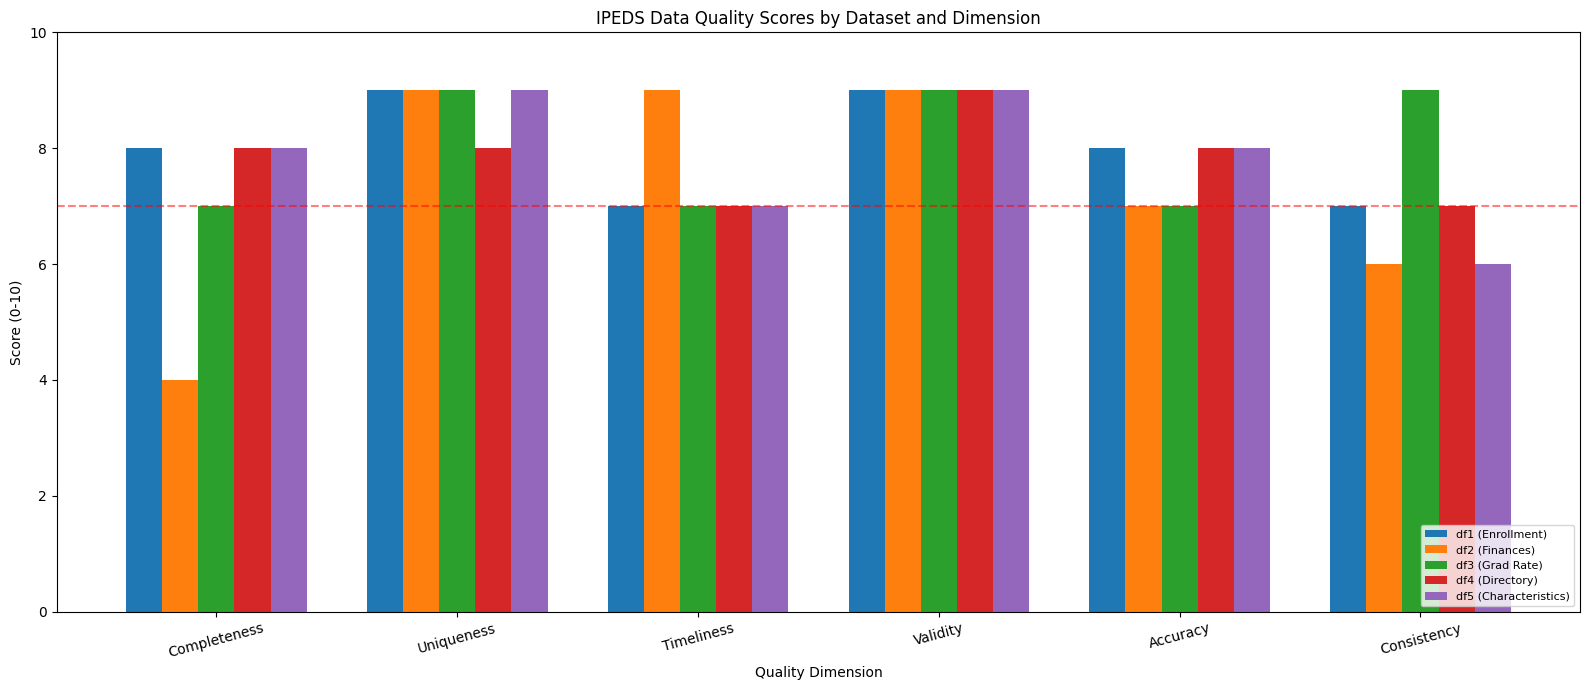

In [ ]:
# Visualize scores as grouped bar chart

datasets = df_scores['Dataset'].tolist()
x = np.arange(len(dimensions))
width = 0.15

fig, ax = plt.subplots(figsize=(16, 7))

for i, (_, row) in enumerate(df_scores.iterrows()):
    values = [row[d] for d in dimensions]
    ax.bar(x + i * width, values, width, label=row['Dataset'])

ax.set_xlabel('Quality Dimension')
ax.set_ylabel('Score (0-10)')
ax.set_title('IPEDS Data Quality Scores by Dataset and Dimension')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(dimensions, rotation=15)
ax.set_ylim(0, 10)
ax.legend(loc='lower right', fontsize=8)
ax.axhline(y=7, color='red', linestyle='--',
           alpha=0.5, label='Minimum acceptable threshold')
plt.tight_layout()
plt.show()

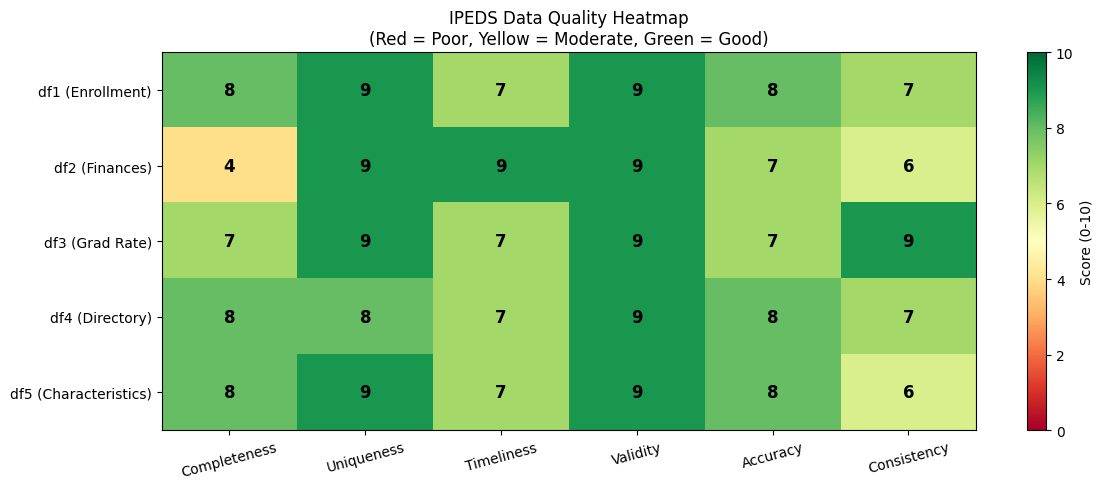

In [ ]:
# Visualize as a heatmap

fig, ax = plt.subplots(figsize=(12, 5))

score_matrix = df_scores[dimensions].values
im = ax.imshow(score_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=10)

ax.set_xticks(range(len(dimensions)))
ax.set_xticklabels(dimensions, rotation=15)
ax.set_yticks(range(len(datasets)))
ax.set_yticklabels([d.split(' - ',1)[-1] if ' - ' in d else d for d in datasets])

for i in range(len(datasets)):
    for j in range(len(dimensions)):
        ax.text(j, i, str(score_matrix[i, j]),
                ha='center', va='center',
                fontweight='bold', fontsize=12)

plt.colorbar(im, ax=ax, label='Score (0-10)')
ax.set_title('IPEDS Data Quality Heatmap\n(Red = Poor, Yellow = Moderate, Green = Good)')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Overall Score Summary
print("Overall Data Quality Summary\n")
print(f"{'Dataset':<25} {'Overall Score':<15} {'Rating'}")
print("-" * 55)

for _, row in df_scores.iterrows():
    score = row['Overall']
    if score >= 9:
        rating = 'Excellent'
    elif score >= 8:
        rating = 'Good'
    elif score >= 7:
        rating = 'Acceptable'
    elif score >= 6:
        rating = 'Needs Attention'
    else:
        rating = 'Critical'

    # Fix: Split by '(' and remove ')' to correctly extract the descriptive name
    dataset = row['Dataset'].split('(')[1].replace(')', '')
    print(f"{dataset:<25} {score:<15} {rating}")

Overall Data Quality Summary

Dataset                   Overall Score   Rating
-------------------------------------------------------
Enrollment                8.0             Good
Finances                  7.3             Acceptable
Grad Rate                 8.0             Good
Directory                 7.8             Acceptable
Characteristics           7.8             Acceptable


## Section 9: Data Quality Scoring Observations

### Data Quality Scores by Dataset (0-10 scale)

| Dataset          | Completeness | Uniqueness | Timeliness | Validity | Accuracy | Consistency | Overall |
|------------------|--------------|------------|------------|----------|----------|-------------|---------|
| df1 Enrollment   | 8            | 9          | 7          | 9        | 8        | 7           | 8.0     |
| df2 Finances     | 4            | 9          | 9          | 9        | 7        | 6           | 7.3     |
| df3 Grad Rate    | 7            | 9          | 7          | 9        | 7        | 9           | 8.0     |
| df4 Directory    | 8            | 8          | 7          | 9        | 8        | 7           | 7.8     |
| df5 Characteristics | 8         | 9          | 7          | 9        | 8        | 6           | 7.8     |


---


### Grouped Bar Chart Observations
- df2 (Finances) Completeness (4) is the only bar falling
  significantly below the red minimum acceptable threshold
  line of 7, making it immediately visible as the audit's
  most critical finding
- Validity is the most consistent dimension — all five
  datasets score 9, producing identical bar heights
- Uniqueness is nearly as strong — four datasets score 9
  with df4 Directory scoring 8
- Consistency shows the most variation across datasets,
  ranging from 6 in df2 (Finances) and df5 (Characteristics)
  to 9 in df3 (Grad Rate)
- Timeliness is uniformly moderate — all datasets score 7
  except df2 (Finances) which scores 9


---


### Heatmap Observations
- The single yellow/orange cell in df2 (Finances) Completeness
  immediately draws the eye, visually communicating the
  most critical finding in the entire audit
- The Validity column is solid dark green across all datasets
  and is the strongest performing dimension visually
- The Consistency column shows the most color variation,
  confirming it as the most uneven dimension across datasets
- df3 (Grad Rate) Consistency of 9 stands out as the darkest
  green in the Consistency column, contrasting sharply with
  df2 (Finances )and df5 (Characteristics) which score 6
- No cell falls into the red zone, indicating no critical
  failures beyond df2 (Finances) Completeness


---


### Overall Data Quality Summary
- df1 Enrollment: 8.0 — Good
- df2 Finances: 7.3 — Acceptable
- df3 Grad Rate: 8.0 — Good
- df4 Directory: 7.8 — Acceptable
- df5 Characteristics: 7.8 — Acceptable


---


No dataset rated below Acceptable overall. The most significant
single finding across the entire audit is df2 (Finances)
Completeness of 4 which is the only score below 6 across all 30
dimension scores evaluated. Without this one finding, df2 (Finances)
would score approximately 8.2, on par with the strongest
datasets in the audit.

Key governance recommendation: The F1A finance file should
not be used as a standalone representation of US higher
education finances. It covers only public GASB institutions
and must be combined with F2 and F3 files for a complete
financial picture of US higher education.



    
  
  
    
  


    

  
    

  
    
  
    

  
    
  

    
  


## Section 10: Visualizations
Standalone visuals exploring patterns, distributions, and
insights across the IPEDS datasets.

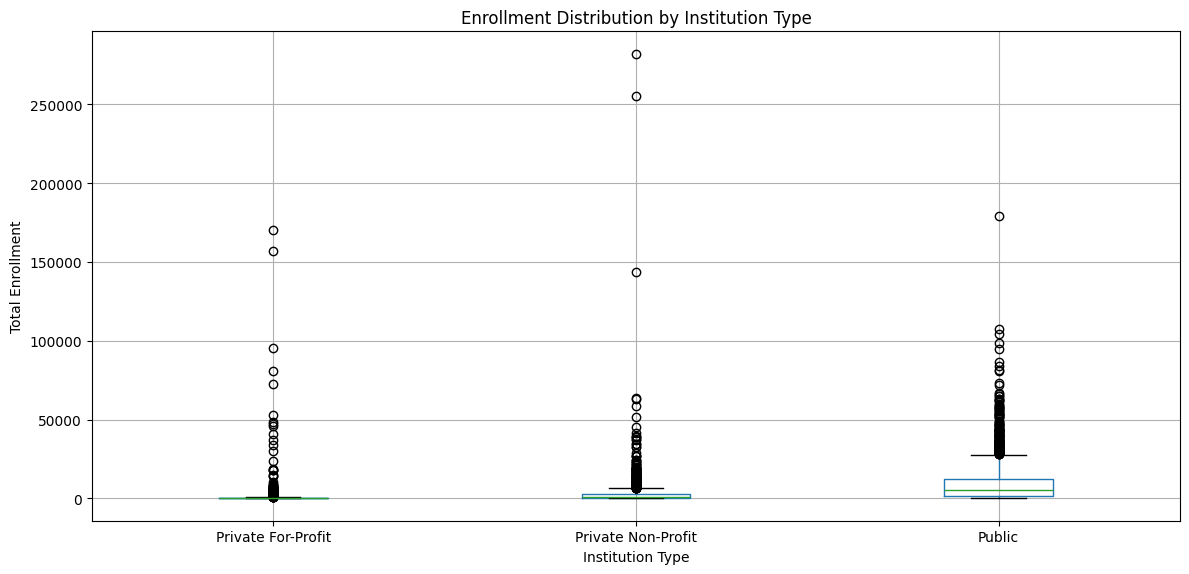

In [ ]:
# Enrollment distribution by institution type, Boxplot

# Merge enrollment totals with directory to get control type
enroll_by_control = df1.groupby('UNITID')['EFYTOTLT'].max().reset_index()
enroll_by_control = enroll_by_control.merge(
    df4[['UNITID', 'CONTROL']], on='UNITID', how='left')

control_labels = {1: 'Public', 2: 'Private Non-Profit', 3: 'Private For-Profit'}
enroll_by_control['CONTROL_LABEL'] = enroll_by_control['CONTROL'].map(control_labels)
enroll_by_control = enroll_by_control[enroll_by_control['CONTROL'] > 0]

fig, ax = plt.subplots(figsize=(12, 6))
enroll_by_control.boxplot(column='EFYTOTLT', by='CONTROL_LABEL', ax=ax)
ax.set_title('Enrollment Distribution by Institution Type')
ax.set_xlabel('Institution Type')
ax.set_ylabel('Total Enrollment')
plt.suptitle('')
plt.tight_layout()
plt.show()

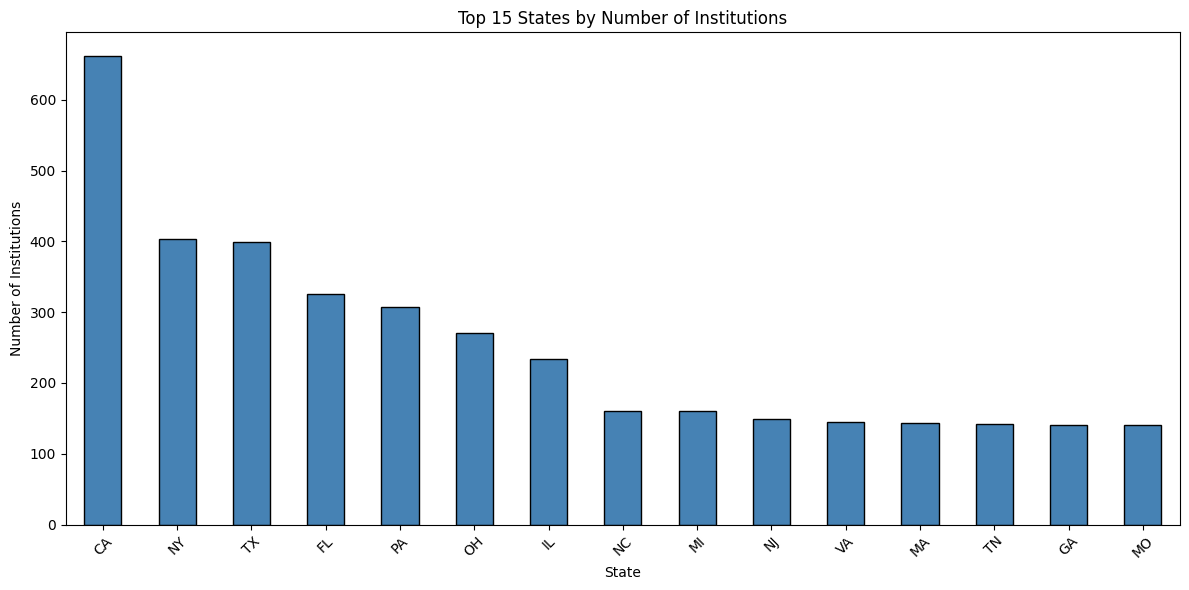

In [ ]:
# Top 15 states by number of institutions, bar chart

state_counts = df4[df4['DEATHYR'] <= 0]['STABBR'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
state_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Top 15 States by Number of Institutions')
ax.set_xlabel('State')
ax.set_ylabel('Number of Institutions')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Investigate CAs high number, for profit?

# Check if CA's high count is driven by for-profit schools
ca_control = df4[(df4['STABBR'] == 'CA') &
                  (df4['DEATHYR'] <= 0) &
                  (df4['CONTROL'] > 0)]['CONTROL'].map(
    {1: 'Public', 2: 'Private Non-Profit',
     3: 'Private For-Profit'}).value_counts()
print("California institutions by control type:")
print(ca_control)

California institutions by control type:
CONTROL
Private For-Profit    296
Public                193
Private Non-Profit    167
Name: count, dtype: int64


In [ ]:
# Check institution control type breakdown for top 4 states
top_states = ['CA', 'NY', 'TX', 'FL']

for state in top_states:
    state_control = df4[(df4['STABBR'] == state) &
                        (df4['DEATHYR'] <= 0) &
                        (df4['CONTROL'] > 0)]['CONTROL'].map(
        {1: 'Public', 2: 'Private Non-Profit',
         3: 'Private For-Profit'}).value_counts()
    total = state_control.sum()
    print(f"\n{state} — Total: {total}")
    for control_type, count in state_control.items():
        pct = (count / total * 100).round(1)
        print(f"  {control_type}: {count} ({pct}%)")


CA — Total: 656
  Private For-Profit: 296 (45.1%)
  Public: 193 (29.4%)
  Private Non-Profit: 167 (25.5%)

NY — Total: 403
  Private Non-Profit: 210 (52.1%)
  Public: 110 (27.3%)
  Private For-Profit: 83 (20.6%)

TX — Total: 399
  Private For-Profit: 213 (53.4%)
  Public: 108 (27.1%)
  Private Non-Profit: 78 (19.5%)

FL — Total: 325
  Private For-Profit: 175 (53.8%)
  Public: 89 (27.4%)
  Private Non-Profit: 61 (18.8%)


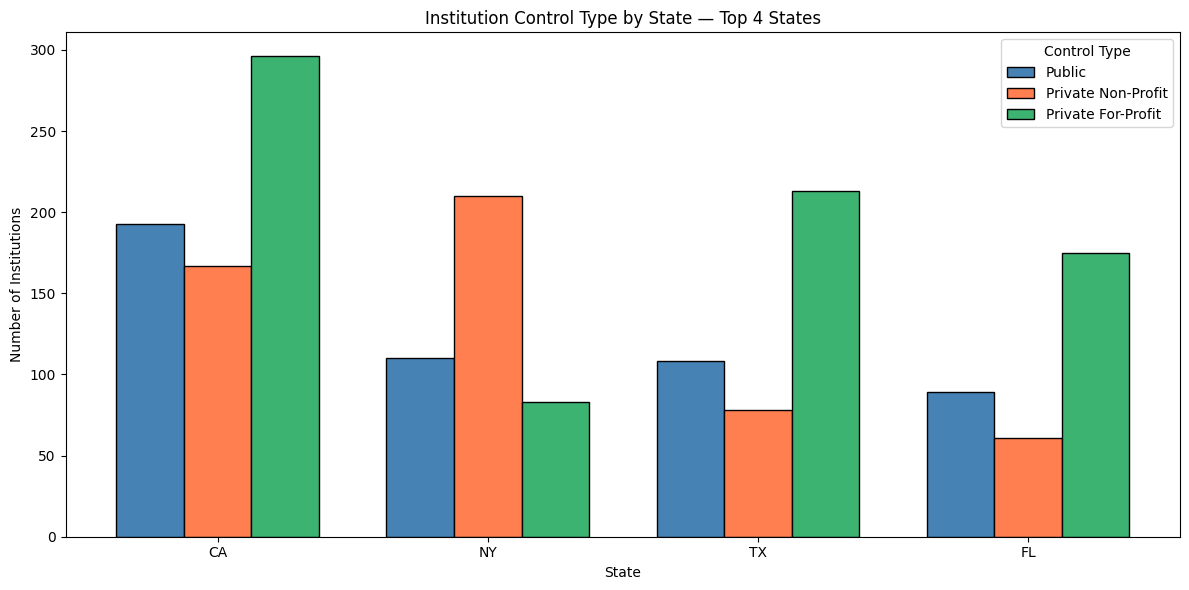

In [ ]:
import numpy as np

state_data = {
    'CA': {'Public': 193, 'Private Non-Profit': 167, 'Private For-Profit': 296},
    'NY': {'Public': 110, 'Private Non-Profit': 210, 'Private For-Profit': 83},
    'TX': {'Public': 108, 'Private Non-Profit': 78, 'Private For-Profit': 213},
    'FL': {'Public': 89, 'Private Non-Profit': 61, 'Private For-Profit': 175}
}

states = list(state_data.keys())
control_types = ['Public', 'Private Non-Profit', 'Private For-Profit']
colors = ['steelblue', 'coral', 'mediumseagreen']

x = np.arange(len(states))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (control, color) in enumerate(zip(control_types, colors)):
    values = [state_data[s][control] for s in states]
    ax.bar(x + i * width, values, width, label=control,
           color=color, edgecolor='black')

ax.set_title('Institution Control Type by State — Top 4 States')
ax.set_xlabel('State')
ax.set_ylabel('Number of Institutions')
ax.set_xticks(x + width)
ax.set_xticklabels(states)
ax.legend(title='Control Type')
plt.tight_layout()
plt.show()

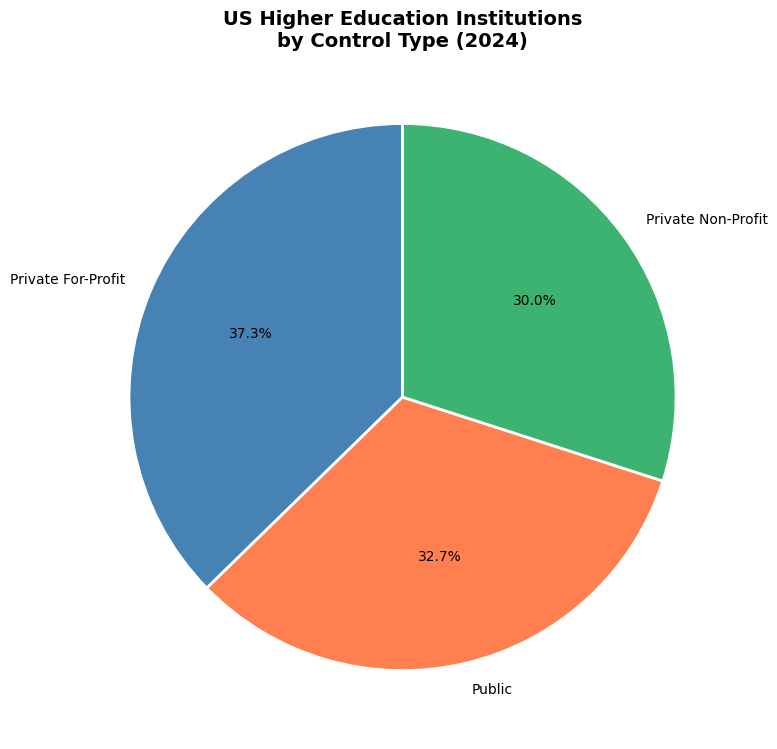

In [ ]:
# Institution control type distribution, pie chart

control_counts = df4[df4['CONTROL'] > 0]['CONTROL'].map(
    {1: 'Public', 2: 'Private Non-Profit', 3: 'Private For-Profit'}
).value_counts()

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(control_counts, labels=control_counts.index, autopct='%1.1f%%',
       colors=['steelblue', 'coral', 'mediumseagreen'],
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('US Higher Education Institutions\nby Control Type (2024)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

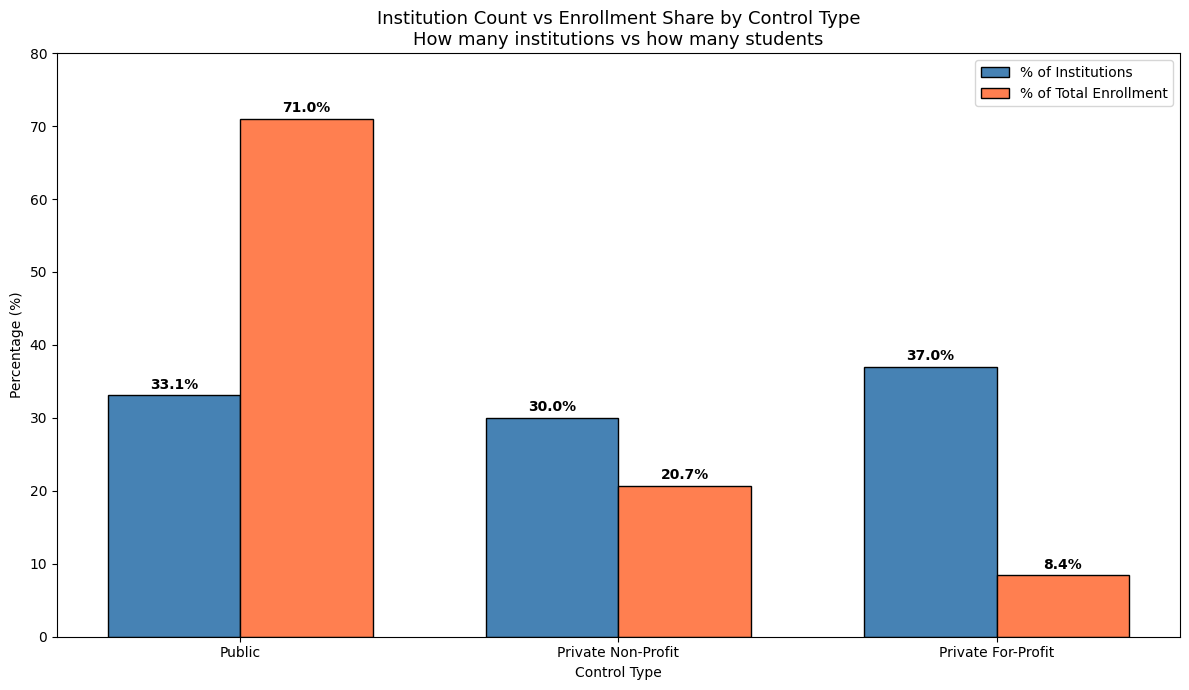

In [ ]:
# Institution count vs enrollment share by control type
control_labels = {1: 'Public', 2: 'Private Non-Profit', 3: 'Private For-Profit'}

# Institution count by control type
inst_counts = df4[(df4['CONTROL'] > 0) &
                   (df4['DEATHYR'] <= 0)]['CONTROL'].map(
    control_labels).value_counts()

# Total enrollment by control type
enroll_by_control = df1.groupby('UNITID')['EFYTOTLT'].max().reset_index()
enroll_by_control = enroll_by_control.merge(
    df4[['UNITID', 'CONTROL']], on='UNITID', how='left')
enroll_by_control['CONTROL_LABEL'] = enroll_by_control['CONTROL'].map(control_labels)
enroll_by_control = enroll_by_control[enroll_by_control['CONTROL'] > 0]
enroll_totals = enroll_by_control.groupby('CONTROL_LABEL')['EFYTOTLT'].sum()

# Convert to percentages
inst_pct = (inst_counts / inst_counts.sum() * 100).round(1)
enroll_pct = (enroll_totals / enroll_totals.sum() * 100).round(1)

# Align indexes
categories = ['Public', 'Private Non-Profit', 'Private For-Profit']
inst_pct = inst_pct.reindex(categories)
enroll_pct = enroll_pct.reindex(categories)

# Plot side by side
x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, inst_pct, width,
               label='% of Institutions',
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, enroll_pct, width,
               label='% of Total Enrollment',
               color='coral', edgecolor='black')

# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height()}%', ha='center', va='bottom', fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height()}%', ha='center', va='bottom', fontweight='bold')

ax.set_title('Institution Count vs Enrollment Share by Control Type\n'
             'How many institutions vs how many students', fontsize=13)
ax.set_xlabel('Control Type')
ax.set_ylabel('Percentage (%)')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_ylim(0, 80)
ax.legend()
plt.tight_layout()
plt.show()

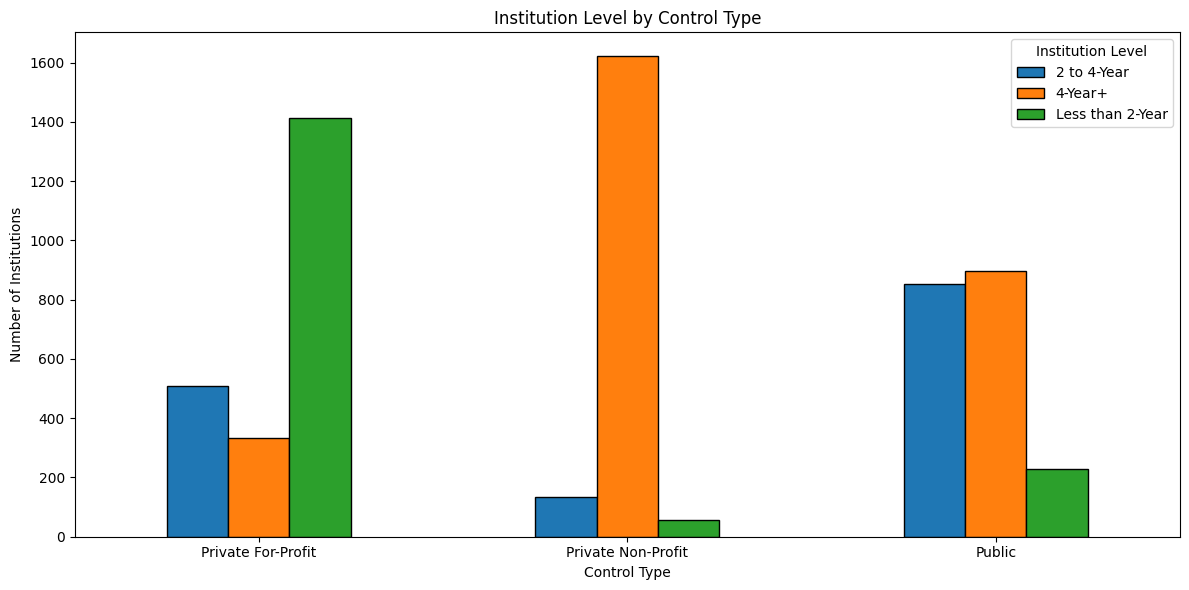

In [ ]:
# Institution level distribution by control type, bar chart

level_control = df4[(df4['CONTROL'] > 0) & (df4['ICLEVEL'] > 0)].copy()
level_control['CONTROL_LABEL'] = level_control['CONTROL'].map(
    {1: 'Public', 2: 'Private Non-Profit', 3: 'Private For-Profit'})
level_control['LEVEL_LABEL'] = level_control['ICLEVEL'].map(
    {1: '4-Year+', 2: '2 to 4-Year', 3: 'Less than 2-Year'})

level_pivot = level_control.groupby(
    ['CONTROL_LABEL', 'LEVEL_LABEL']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
level_pivot.plot(kind='bar', ax=ax, edgecolor='black')
ax.set_title('Institution Level by Control Type')
ax.set_xlabel('Control Type')
ax.set_ylabel('Number of Institutions')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Institution Level')
plt.tight_layout()
plt.show()

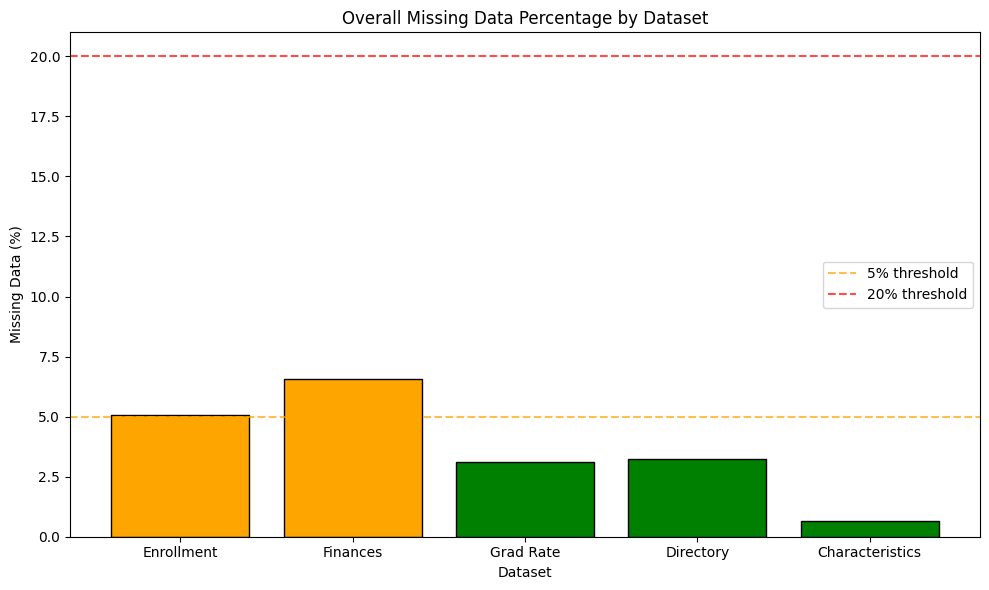

In [ ]:
# Missing data summary, bar chart

missing_summary = {}
for name, df in [('Enrollment', df1), ('Finances', df2),
                  ('Grad Rate', df3), ('Directory', df4),
                  ('Characteristics', df5)]:
    total = df.shape[0] * df.shape[1]
    missing = df.isnull().sum().sum()
    missing_summary[name] = round((missing / total) * 100, 2)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['green' if v < 5 else 'orange' if v < 20 else 'red'
          for v in missing_summary.values()]
ax.bar(missing_summary.keys(), missing_summary.values(),
       color=colors, edgecolor='black')
ax.set_title('Overall Missing Data Percentage by Dataset')
ax.set_xlabel('Dataset')
ax.set_ylabel('Missing Data (%)')
ax.axhline(y=5, color='orange', linestyle='--',
           alpha=0.7, label='5% threshold')
ax.axhline(y=20, color='red', linestyle='--',
           alpha=0.7, label='20% threshold')
ax.legend()
plt.tight_layout()
plt.show()

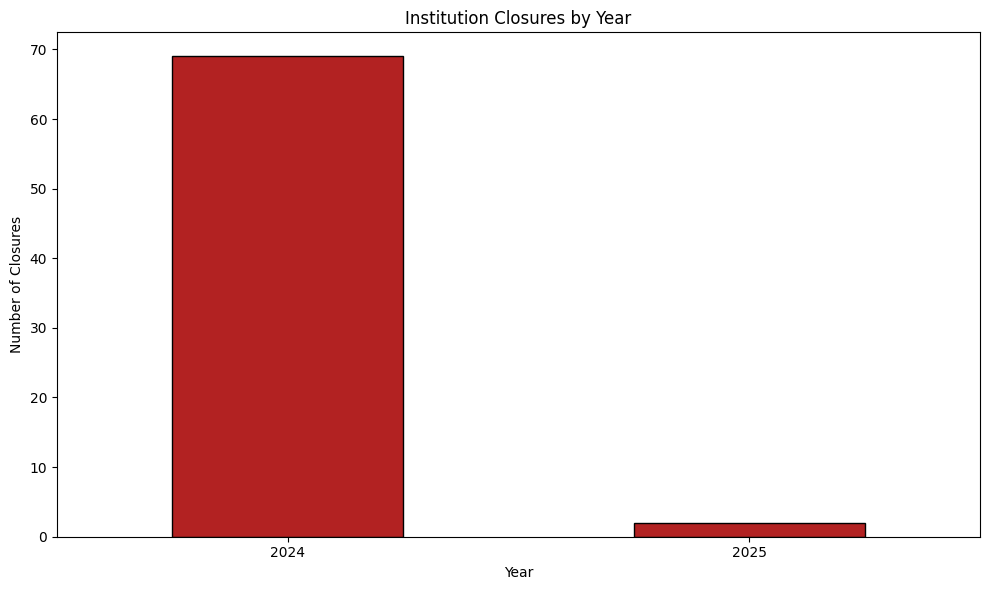

In [ ]:
# Closed institutions by year

closed_by_year = df4[df4['DEATHYR'] > 0]['DEATHYR'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 6))
closed_by_year.plot(kind='bar', ax=ax, color='firebrick', edgecolor='black')
ax.set_title('Institution Closures by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Closures')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

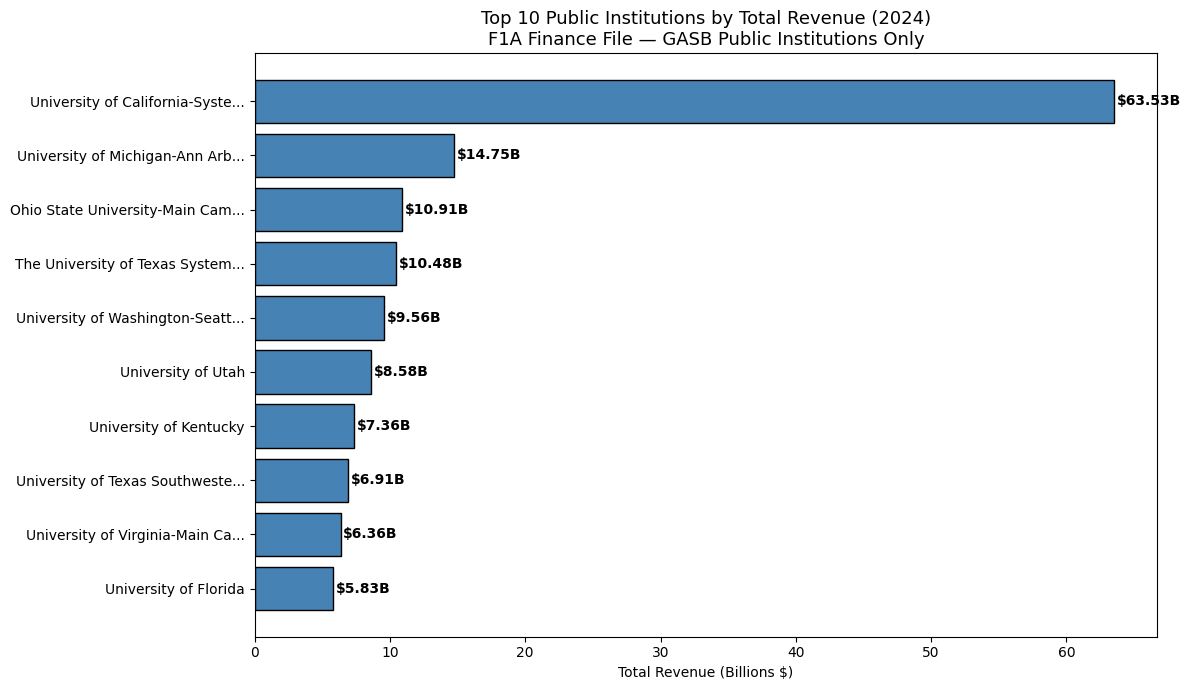

In [ ]:
# Top 10 institutions by total revenue
top_revenue = df2[['UNITID', 'F1D01']].sort_values(
    'F1D01', ascending=False).head(10)

# Get institution names from df4
top_revenue = top_revenue.merge(
    df4[['UNITID', 'INSTNM', 'STABBR']], on='UNITID', how='left')

# Shorten long institution names for display
top_revenue['SHORT_NAME'] = top_revenue['INSTNM'].apply(
    lambda x: x[:30] + '...' if len(x) > 30 else x)

# Convert to billions for readability
top_revenue['REVENUE_B'] = (top_revenue['F1D01'] / 1e9).round(2)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_revenue['SHORT_NAME'], top_revenue['REVENUE_B'],
               color='steelblue', edgecolor='black')

# Add value labels on bars
for bar, val in zip(bars, top_revenue['REVENUE_B']):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f'${val}B', va='center', fontweight='bold')

ax.set_title('Top 10 Public Institutions by Total Revenue (2024)\n'
             'F1A Finance File — GASB Public Institutions Only',
             fontsize=13)
ax.set_xlabel('Total Revenue (Billions $)')
ax.set_ylabel('')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## Section 10: Visualizations Observations

#### Enrollment Distribution by Institution Type, Boxplot
- Private, For-Profit has the most compressed box of all three. The vast majority of these institutions are very small. There are several outliers found up to 170,000 (for example, Grand Canyon University and University of Phoenix)
- Private, Non-Profit has a slightly larger median than For-Profit, but still small. Two extreme ouliers are observed by Western Governors University (255,000) and Southern New Hampshire University (280,000); both fully online institutions
- Public has the widest and tallest box of all three. These institutions have the most consistent mid-range enrollment and the highest median enrollment. Outliers up to 180,000 represent large state university systems

Governance insight: Extreme outliers in the private sector are almost entirely online institutions. Removing online institutions would dramatically shrink the private boxes while having little effect on public

---

#### Top 15 States by Number of Institutions, Bar Chart
California leads with over 650 institutions, followed by New York and Texas with approximately 400 each. Florida is next with about 350. There is a steady decrease in Pennsylvania, Ohio, and Illinois, followed by a marked drop-off with North Carolina at around 190 where the chart stays flat through the final 7 of 15 states.

---
#### Institution Control Type — Top 4 State Comparison, Clustered Bar Chart
CA, NY, TX and FL show dramatically different institutional
profiles despite being the four largest states by institution count:

- California: For-profit dominated (45%) with the highest
  raw for-profit count of any state (296)
- New York: The only state where Private Non-Profit dominates
  (52%), reflecting NYC's dense concentration of private universities and specialized institutions
- Texas: For-profit dominated (53%) with a small nonprofit sector (19.5%)
- Florida: Most heavily for-profit dominated of all four states (53.8%) with the smallest nonprofit sector (18.8%)

Findings: Public institution counts are
remarkably consistent across all four states at 27-29% of total institutions, regardless of overall size or for-profit concentration. This suggests public higher education infrastructure scales proportionally with state population while the private sector composition
varies dramatically by state.

---
#### Institution Control Type Distribution, Pie Chart
- Private, For-Profit: 37.3%
- Private, Non-Profit: 30.0%
- Public: 32.7%

---
#### Institution Count vs Enrollment Share by Control Type, Clustered Bar Chart

Public institutions:
- 33.1% of all institutions
- 71.0% of total enrollment
- Serve 2.1x their proportional share of students

Private Non-Profit:
- 30.0% of all institutions  
- 20.7% of total enrollment
- Slightly underrepresented in enrollment vs institution count

Private For-Profit:
- 37.0% of all institutions — the largest sector by count
- Only 8.4% of total enrollment — the smallest sector by students
- The average for-profit institution serves dramatically fewer students than public or nonprofit counterparts

Key governance finding: Institution count and enrollment share tell completely opposite stories about US higher education. For-profit institutions dominate by count but
are nearly invisible by enrollment. Public institutions appear to be one of three equal sectors by count but actually serve nearly three quarters of all students.

Any policy analysis, funding decision, or governance framework that uses institution counts as a proxy for educational impact will significantly overestimate the role of for-profit institutions and underestimate the
dominance of public higher education

---
#### Institution Level by Control Type, Clustered Bar Chart
Private For-Profit:
- Dominated by Less than 2-Year institutions (1,400+)
- Confirms the for-profit sector is primarily short-term vocational and certificate programs
- Very few 4-Year+ degree-granting for-profit institutions

Private Non-Profit:
- Almost entirely 4-Year+ institutions (1,600+)
- Traditional private colleges are overwhelmingly degree-granting four-year institutions
- Nearly zero Less than 2-Year nonprofit institutions

Public:
- Most balanced distribution of all three sectors
- Nearly equal split between 4-Year+ (900) and
  2 to 4-Year (850) institutions
- Reflects the dual role of public higher education — university education AND community college access
- Less than 2-Year public institutions are relatively rare (230)

Key governance finding: The three sectors serve
fundamentally different educational missions. For-profits focus on short-term certificates, nonprofits focus on four-year degrees, and public institutions serve both roles. Any cross-sector comparison must account for
these structural differences in institutional mission and program length

---
#### Missing Data Percentage by Dataset, Bar Chart
Color coding: Green = below 5%, Orange = below 20%
No dataset exceeded the 20% threshold.

- Characteristics: 0.6% — cleanest dataset, DISABPCT missingness is by design
- Grad Rate: 3.1% — below threshold, missing values expected for non-degree granting institutions
- Directory: 3.2% — below threshold, missing values concentrated in optional URL fields
- Enrollment: 5.1% — marginally above 5% threshold, driven by rarely reported gender "another" columns
- Finances: 6.6% — highest missing rate, driven by widespread unreported fields across 97 columns

Key finding: No dataset exceeds the 20% threshold, indicating IPEDS maintains acceptable overall data completeness. However the cell-level missing percentage understates the true completeness concern in df2 (Finances). The 68.5% institution coverage gap identified in Section 5 is a more meaningful completeness metric than the raw missing cell percentage for the df2 (Finances) dataset.

---

#### Top 10 Public Institutions by Total Revenue (2024), Bar Chart
Data source: F1A Finance File — GASB Public Institutions Only

- University of California System leads dramatically at 63.53B USD — over 4x the second place institution. This reflects system-level consolidation across all UC campuses
- University of Michigan (14.75B USD) and Ohio State (10.91B USD) are the top single-campus institutions by revenue
- University of Texas System (10.48B USD) is also system-level
- Positions 2-10 cluster between 5.83B USD and 14.75B USD, suggesting a competitive tier of large flagship research universities
- University of Utah, University of Kentucky, and UT Southwestern all appear in the top 10, likely driven by large academic medical centers and health systems rather than tuition revenue alone

Important context: This chart represents public GASBinstitutions only. Private institutions (Harvard, MIT, Stanford endowment-driven revenues) are not included
in this file and would likely appear in the top rankings if the full IPEDS finance dataset were used.


## Section 11: Governance Framework Mapping
Mapping audit findings to formal data governance frameworks.
This section connects technical findings to governance
recommendations using DAMA DMBOK and related standards.

In [ ]:
# Create a findings summary table

import pandas as pd

findings = [
    {
        'Dataset': 'df2 - Finances',
        'Finding': 'F1A file covers only 31.5% of IPEDS institutions',
        'DMBOK Dimension': 'Completeness',
        'Severity': 'High',
        'DAMA Category': 'Data Architecture',
        'Recommendation': 'Merge F1A, F2, and F3 finance files for complete coverage'
    },
    {
        'Dataset': 'df1, df2',
        'Finding': 'No internal year column — reporting year in filename only',
        'DMBOK Dimension': 'Timeliness',
        'Severity': 'Medium',
        'DAMA Category': 'Data Quality',
        'Recommendation': 'Add REPORT_YEAR column to make datasets self-documenting'
    },
    {
        'Dataset': 'All datasets',
        'Finding': 'Negative values used as coding conventions throughout',
        'DMBOK Dimension': 'Consistency',
        'Severity': 'Medium',
        'DAMA Category': 'Data Quality',
        'Recommendation': 'Document all negative coding conventions in a data dictionary. '
                          'Consider using NULL instead of negative codes'
    },
    {
        'Dataset': 'df4 - Directory',
        'Finding': 'BOM encoding issue on UNITID column',
        'DMBOK Dimension': 'Consistency',
        'Severity': 'Medium',
        'DAMA Category': 'Data Integration',
        'Recommendation': 'Standardize file encoding to UTF-8-SIG across all IPEDS files'
    },
    {
        'Dataset': 'df1, df3, df5',
        'Finding': 'Closed institutions still reporting data',
        'DMBOK Dimension': 'Timeliness',
        'Severity': 'Medium',
        'DAMA Category': 'Master Data Management',
        'Recommendation': 'Apply DEATHYR filter before any cross-dataset analysis. '
                          'Flag closed institution records automatically'
    },
    {
        'Dataset': 'df4 - Directory',
        'Finding': 'Shared OPEIDs between admin offices and degree-granting institutions',
        'DMBOK Dimension': 'Uniqueness',
        'Severity': 'High',
        'DAMA Category': 'Reference Data Management',
        'Recommendation': 'Review and correct shared OPEIDs. Administrative entities '
                          'should not share federal aid identifiers with campuses'
    },
    {
        'Dataset': 'df2 - Finances',
        'Finding': 'Federally operated institutions follow different accounting standards',
        'DMBOK Dimension': 'Accuracy',
        'Severity': 'Medium',
        'DAMA Category': 'Data Quality',
        'Recommendation': 'Flag federal institutions separately in any financial analysis. '
                          'Document known exceptions in metadata'
    },
    {
        'Dataset': 'df4 - Directory',
        'Finding': '11 major universities missing street addresses',
        'DMBOK Dimension': 'Completeness',
        'Severity': 'Low',
        'DAMA Category': 'Data Quality',
        'Recommendation': 'Flag for correction in next data collection cycle'
    },
    {
        'Dataset': 'df3 - Grad Rate',
        'Finding': 'COHORT column name misleading — contains category code not headcount',
        'DMBOK Dimension': 'Accuracy',
        'Severity': 'Medium',
        'DAMA Category': 'Metadata Management',
        'Recommendation': 'Rename column to COHORT_TYPE or add clear documentation '
                          'to prevent misinterpretation by analysts'
    },
    {
        'Dataset': 'All datasets',
        'Finding': 'Pacific Island institutions require special handling in geographic analysis',
        'DMBOK Dimension': 'Accuracy',
        'Severity': 'Low',
        'DAMA Category': 'Data Quality',
        'Recommendation': 'Create a territory flag column to identify non-continental '
                          'US institutions for geospatial filtering'
    },
    {
        'Dataset': 'df1, df3',
        'Finding': 'Online institutions skew enrollment and graduation rate comparisons',
        'DMBOK Dimension': 'Consistency',
        'Severity': 'Medium',
        'DAMA Category': 'Data Quality',
        'Recommendation': 'Add delivery method flag to segment online vs residential '
                          'institutions before comparative analysis'
    },
    {
        'Dataset': 'df4 - Directory',
        'Finding': 'Institution count vs enrollment share disconnect by control type',
        'DMBOK Dimension': 'Accuracy',
        'Severity': 'Low',
        'DAMA Category': 'Data Quality',
        'Recommendation': 'Always pair institution counts with enrollment figures '
                          'to avoid misleading policy conclusions'
    }
]

df_findings = pd.DataFrame(findings)
print(f"Total findings documented: {len(df_findings)}")
display(df_findings)

Total findings documented: 12


,Dataset,Finding,DMBOK Dimension,Severity,DAMA Category,Recommendation
0,df2 - Finances,F1A file covers only 31.5% of IPEDS institutions,Completeness,High,Data Architecture,"Merge F1A, F2, and F3 finance files for comple..."
1,"df1, df2",No internal year column — reporting year in fi...,Timeliness,Medium,Data Quality,Add REPORT_YEAR column to make datasets self-d...
2,All datasets,Negative values used as coding conventions thr...,Consistency,Medium,Data Quality,Document all negative coding conventions in a ...
3,df4 - Directory,BOM encoding issue on UNITID column,Consistency,Medium,Data Integration,Standardize file encoding to UTF-8-SIG across ...
4,"df1, df3, df5",Closed institutions still reporting data,Timeliness,Medium,Master Data Management,Apply DEATHYR filter before any cross-dataset ...
5,df4 - Directory,Shared OPEIDs between admin offices and degree...,Uniqueness,High,Reference Data Management,Review and correct shared OPEIDs. Administrati...
6,df2 - Finances,Federally operated institutions follow differe...,Accuracy,Medium,Data Quality,Flag federal institutions separately in any fi...
7,df4 - Directory,11 major universities missing street addresses,Completeness,Low,Data Quality,Flag for correction in next data collection cycle
8,df3 - Grad Rate,COHORT column name misleading — contains categ...,Accuracy,Medium,Metadata Management,Rename column to COHORT_TYPE or add clear docu...
9,All datasets,Pacific Island institutions require special ha...,Accuracy,Low,Data Quality,Create a territory flag column to identify non...


In [ ]:
from pandas.core.indexes import category
# Severity summary

print("Findings by Severity\n")
severity_counts = df_findings['Severity'].value_counts()
for severity, count in severity_counts.items():
    print(f"{severity}: {count} findings")

print("\nFindings by DAMA Category\n")
category_counts = df_findings['DAMA Category'].value_counts()
for category, count in category_counts.items():
    print(f"{category}: {count} findings")

print("\nFindings by DMBOK Dimension\n")
dimension_counts = df_findings['DMBOK Dimension'].value_counts()
for dimension, count in dimension_counts.items():
    print(f"{dimension}: {count} findings")

Findings by Severity

Medium: 7 findings
Low: 3 findings
High: 2 findings

Findings by DAMA Category

Data Quality: 7 findings
Data Architecture: 1 findings
Data Integration: 1 findings
Master Data Management: 1 findings
Reference Data Management: 1 findings
Metadata Management: 1 findings

Findings by DMBOK Dimension

Accuracy: 4 findings
Consistency: 3 findings
Completeness: 2 findings
Timeliness: 2 findings
Uniqueness: 1 findings


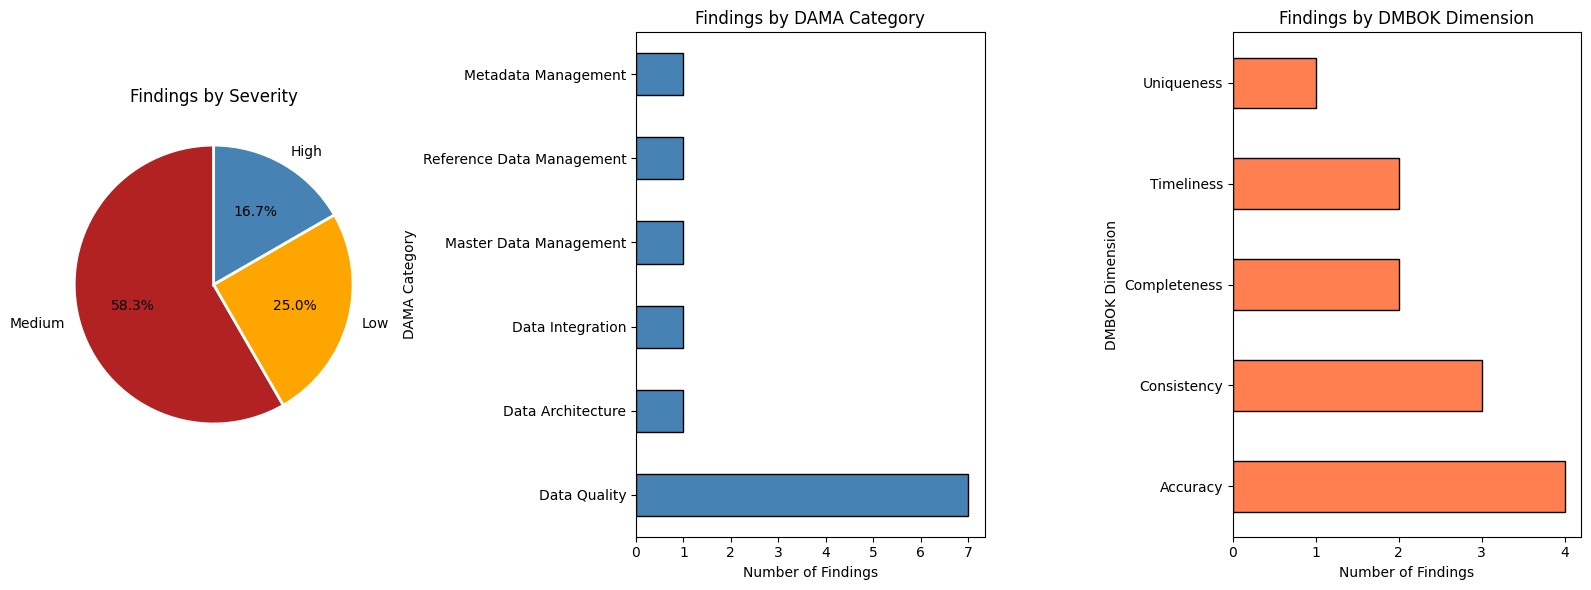

In [ ]:
# Visualize findings by severity and category

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Severity pie chart
severity_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                     colors=['firebrick', 'orange', 'steelblue'],
                     startangle=90,
                     wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Findings by Severity')
axes[0].set_ylabel('')

# DAMA Category bar chart
category_counts.plot(kind='barh', ax=axes[1],
                     color='steelblue', edgecolor='black')
axes[1].set_title('Findings by DAMA Category')
axes[1].set_xlabel('Number of Findings')

# DMBOK Dimension bar chart
dimension_counts.plot(kind='barh', ax=axes[2],
                      color='coral', edgecolor='black')
axes[2].set_title('Findings by DMBOK Dimension')
axes[2].set_xlabel('Number of Findings')

plt.tight_layout()
plt.show()

## DAMA DMBOK Framework Alignment

This audit applied all six DAMA DMBOK data quality dimensions:

1. COMPLETENESS
   Most critical finding: df2 (Finance) file covers only 31.5%
   of IPEDS institutions due to scope limitation (GASB public
   institutions only). Recommendation: Combine F1A, F2, F3.

2. UNIQUENESS
   Most critical finding: Shared OPEIDs between administrative
   offices and degree-granting institutions raises federal
   aid compliance concerns. Recommendation: Review and
   correct all shared OPEIDs.

3. TIMELINESS
   Most critical finding: No internal year columns in df1 (Enrollment)
   or df2 (Finances). Reporting year exists only in filenames.
   Recommendation: Add REPORT_YEAR column to all datasets.

4. VALIDITY
   Strongest dimension across all datasets. ZIP codes,
   state abbreviations, categorical codes all conform
   to defined allowable value sets. No critical findings.

5. ACCURACY
   Most critical finding: Federally operated institutions
   follow different accounting standards, making financial
   comparisons misleading without flagging. Recommendation:
   Create federal institution flag in master data.

6. CONSISTENCY
   Most critical finding: Negative coding conventions used
   across hundreds of columns requiring extensive domain
   knowledge. Recommendation: Document all conventions in
   a centralized data dictionary.


### Related Governance Frameworks

FAIR Data Principles (Findable, Accessible, Interoperable, Reusable):
- Findable: UNITID provides reliable unique identification ✓
- Accessible: Public dataset freely available ✓
- Interoperable: Negative coding conventions reduce
  interoperability without domain knowledge ✗
- Reusable: Filename-only year identification reduces
  reusability for longitudinal analysis ✗

NIST Data Management:
- Referential integrity is strong — 100% UNITID match
  across all datasets ✓
- Encoding inconsistency, BOM on df4 (Directory), is a minor
  interoperability risk ✗

ISO 8000 Data Quality Standard:
- Data is syntactically correct with valid formats ✓
- Data is semantically complete for intended purpose
  with noted exceptions ✓
- Provenance is documented through IPEDS data dictionary ✓

## Section 11: Governance Framework Mapping Observations

### Findings Summary
12 total findings documented across all six DAMA DMBOK
data quality dimensions and five IPEDS datasets.

---

#### Findings by Severity
- High: 2 findings (16.7%)
- Medium: 7 findings (58.3%)
- Low: 3 findings (25.0%)

The majority of findings are Medium severity, indicating
that IPEDS data has real governance concerns that require
attention but no catastrophic failures. The 2 High severity
findings are the most actionable priorities:
1. df2 (Finance): file covers only 31.5% of institutions
2. df4 (Directory): shared OPEIDs between administrative offices and
   degree-granting institutions

---

#### Findings by DAMA Category
- Data Quality: 7 findings (58.3%)
- Data Architecture: 1 finding
- Data Integration: 1 finding
- Master Data Management: 1 finding
- Reference Data Management: 1 finding
- Metadata Management: 1 finding

Data Quality accounts for the majority of findings, which
is expected for a data quality audit. The presence
of findings across 5 other DAMA categories indicates
that IPEDS governance concerns extend beyond simple data
quality into architecture, integration, master data,
reference data, and metadata management. A comprehensive
governance program would need to address all five areas.

---

#### Findings by DMBOK Dimension
- Accuracy: 4 findings
- Consistency: 3 findings
- Completeness: 2 findings
- Timeliness: 2 findings
- Uniqueness: 1 finding
- Validity: 0 findings

Accuracy is the most problematic dimension with 4 findings,
driven primarily by contextual interpretation challenges such as
federally operated institutions, misleading column names,
Pacific Island geographic handling, and the institution
count vs enrollment share disconnect. These are not data
entry errors but rather data design and documentation gaps
that require governance intervention.

Zero findings in the Validity dimension confirms that IPEDS data
conforms well to defined formats and allowable value sets. The data is structurally sound even where contextual interpretation is challenging.

## Section 12: Executive Summary

#### Project Overview
This project presents a comprehensive data quality audit of five datasets from the Integrated Postsecondary Education Data System (IPEDS), published by the National Center for Education Statistics (NCES) under the U.S. Department of Education. IPEDS is the primary source of data on U.S. higher education institutions. The institution-reported data collected for this audit includes enrollment, finances, graduation rates, directory information, and institutional characteristics for over 6,000 institutions nationwide.

The audit was conducted using the DAMA DMBOK framework, evaluating data across six quality dimensions: Completeness, Uniqueness, Timeliness, Validity, Accuracy, and Consistency. Python was used for all data profiling, analysis, and visualization in Google Colab. Excel was used for confirmation purposes.

---
#### Datasets Audited
- df1: 12-Month Enrollment by Race and Gender<br>File name: effy2024<br>115,026 rows  |  72 columns  |  5,861 unique institutions
- df2: Financial Data - Public GASB Institutions<br>File name: f2324_f1a<br>1,911 rows  |  288 columns  |  1,911 unique institutions
- df3: Graduation Rate<br>File name: gr2024<br>51,011 rows  |  66 columns  |  3,684 unique institutions
- df4: Institution Directory<br>File name: hd2024<br>6,072 rows  |  72 columns  |  6,072 unique institutions
- df5: Institution Characteristics<br>File name: ic2024<br>5,963 rows  |  111 columns  |  5,963 unique institutions

---

#### Overall Data Quality Results
| Dataset          | Overall Score | Rating      |
|------------------|---------------|-------------|
| df1 Enrollment   | 8.0           | Good        |
| df2 Finances     | 7.3           | Acceptable  |
| df3 Grad Rate    | 8.0           | Good        |
| df4 Directory    | 7.8           | Acceptable  |
| df5 Characteristics | 7.8        | Acceptable  |

No dataset rated below Acceptable. IPEDS data is generally well structured and suitable for research and policy analysis with appropriate domain knowledge.

---

### Key Findings

#### Finding 1 - High Severity
Finance File Coverage Gap, df2 (Finances)<br>
The F1A finance file covers 1,911 of 6,072 IPEDS institutions (31.5%). This file only includes financial data for public institutions using GASB accounting standards. Private institutions are reported separately in files not included in this audit. Any financial analysis using only F1A without this context will misrepresent US higher education finances.<br>
**Recommendation: If analysis only concerns public instititutions, the use of F1A alone is justified. If including private institution data, combine for complete analysis.**

#### Finding 2 - High Severity
Shared OPEIDs - Federal Aid Compliance Risk, df4 (Directory)<br>
OPEID is the primary identifier used for federal student aid disbursement and tracking. 39 OPEIDs are shared across multiple institutions. While most reflect legitimate relationships, instances where administrative boards and offices share OPEIDs with degree-granting campuses raise federal financial aid compliance concerns. This could be user data-entry error. <br>
**Recommendation: Review and correct all shared OPEIDs.**

#### Finding 3 - Medium Severity
Negative Coding Conventions, All datasets<br>
IPEDS uses negative values (-1, -2, -3) as coding conventions throughout the datasets to indicate not applicable, not reported, and suppressed data. This affects hundreds of columns across all five datasets. Without the IPEDS data dictionaries, which are available via separate download from the datasets, these values appear to be data errors. The dictionaries related to some datasets define these values, while others do not. This reduces interoperability for analysts unfamiliar with IPEDS.<br>
**Recommendation: Document all negative coding conventions in a centralized metadata repository. Consider replacing negative codes with NULL values and separate flag columns.**

#### Finding 4 - Medium Severity
Closed Institutions Still Reporting, df1 (Enrollment), df3 (Grad Rate), df5 (Characteristics)<br>
34 instances of closed institutions appeared across enrollment, graduation rate, and characteristics datasets. Most closed during the 2024 reporting year and submitted partial year data prior to closure. The df2 (Finances) dataset does not include any closed institutions.<br>
**Recommendation: Apply DEATHYR filter from df4 (Directory) before any cross-dataset analysis to exclude closed institutions.**

#### Finding 5 - Medium Severity
No Internal Year Column, df1 (Enrollment), df2 (Finances)<br>
There are no internal columns identifying the reporting year within the df1 (Enrollment) and df2 (Finances) datasets. Year information exists only in the file names, effy2024 and f2324, respectively. If files are renamed or combined with other years, there is no method to match data with year reported.<br>
**Recommendation: Add a REPORT_YEAR column to all IPEDS datasets to create self-documentation and allow safe longitudinal analysis.**

#### Finding 6 - Medium Severity
BOM Encoding Issue, df4 (Directory)<br>
The UNITID column in df4 (Directory) contained a Byte Order Mark (BOM) character when loaded with standard Latin-1 encoding. This made the column unrecognizable. Error was resolved by changing the encoding to UTF-8-SIG. Undetected, this issue would cause all UNITID-based joins to fail.<br>
**Recommendation: Standardize file encoding to UTF-8-SIG across all IPEDS files.**


---
#### Institutional Landscape Findings
Beyond data quality, this audit produced several significant findings about US higher education:
- Private, For-Profit institutions are the most numerous sector at 37.3%, but serve only 8.4% of students. Conversely, Public institutions represent 33% of institutions, while serving 71% of students.
- Online institutions dominate the top 10 enrollment rankings. Western Governors University and Southern New Hampshire University are the two largest institutions by enrollment with 282,150 and 255,134 students, respectively.
- 71 institutions closed during the 2024-2025 school year. These were almost entirely small, For-Profit vocational schools.
- California contains the most institutions with 656. This is nearly the count of the next two states (New York and Texas) combined. Both California and Texas, along with fourth-place Florida, are overrepresented by For-Profit vocational schools, while New York has a 52% majority of Private, Non-Profit institutions. This reflects the dense concentration of NYC's private universities.
- Public institution counts are noticeably consistent at 27-29% across the top four states (by total institution count) regardless of overall state size.

---

#### **Additional Governance Recommendations**
- Add delivery method flag to segment online vs residential institutions in comparative analysis
- Add territory flag for Pacific Island institutions in geospatial analysis
- Flag federally operated institutions in financial analysis
- Pair institution counts with enrollment figures to avoid misleading data and policy conclusions

---

#### Methodolgy Note
This audit was conducted on 2024 provisional release data. IPEDS provisional data may differ from final release data as institutions submit corrections during the subsequent data collection year. All findings should be verified against final release data before informing policy decisions.

All analysis was conducted in Python using pandas, matplotlib, seaborn, and missingnolibraries in Google Colab. The DAMA DMBOK framework was used as the primary goverance reference. IPEDS data dictionaries were consulted throughout to define column names and to distinguish legitimate coding conventions from true data quality issues.


  
  
  